# 랜덤 포레스트 실습 - 통신고객이탈 분류

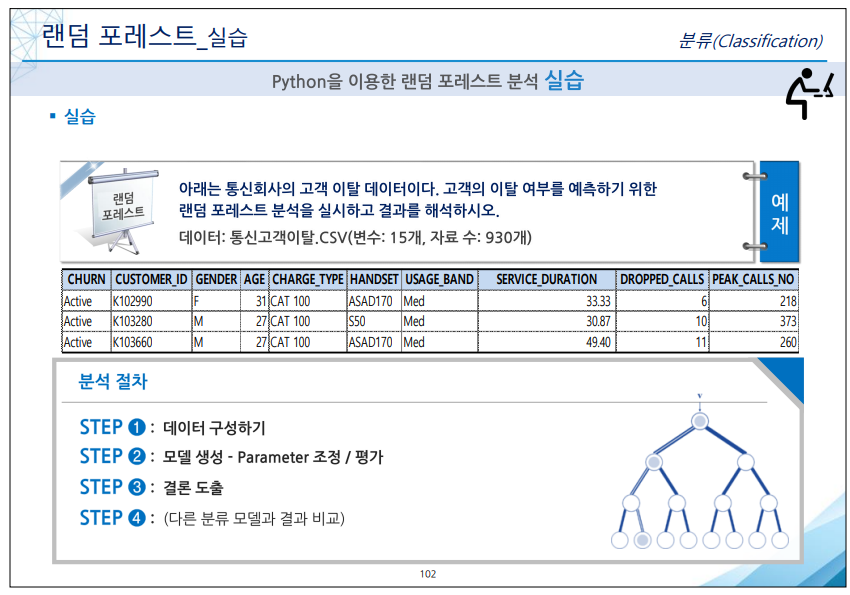

#### 패키지 불러오기

In [1]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 데이터 분할:train, test
from sklearn.model_selection import train_test_split
#분류 Random Forest
from sklearn.ensemble import RandomForestClassifier
# 최적 모델, 파라미터 탐색
from sklearn.model_selection import GridSearchCV

# 분류모델 평가 함수
from sklearn.metrics import accuracy_score, f1_score 
from sklearn.metrics import confusion_matrix, classification_report

#### 그래프 옵션 지정

In [2]:
# 그래프 한글폰트 적용:맑은 고딕
matplotlib.rc("font", family = "Malgun Gothic")
# 그래프 (-) 기호 표시
matplotlib.rc("axes", unicode_minus = False)

## 데이터 구성하기

#### 데이터 불러오기

In [3]:
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\통신고객이탈.csv", encoding='cp949')
df_raw.head()

,CHURN,CUSTOMER_ID,GENDER,AGE,CHARGE_TYPE,HANDSET,USAGE_BAND,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,Active,K102990,F,31,CAT 100,ASAD170,Med,33.33,6,218,379.8,9,21.6,366,632.4
1,Active,K103280,M,27,CAT 100,S50,Med,30.87,10,373,656.4,11,28.0,411,810.4
2,Active,K103660,M,27,CAT 100,ASAD170,Med,49.40,11,260,582.0,0,0.0,265,614.1
3,Active,K103730,M,61,CAT 100,ASAD170,Med,48.60,1,294,661.8,14,101.5,326,844.0
4,Active,K104560,F,52,CAT 100,S50,Med,56.03,0,221,555.6,7,25.0,274,673.0


In [4]:
# Data 구조 확인
print("Data 구조:", df_raw.shape)
print()
print("변수 : ", df_raw.columns)

Data 구조: (930, 15)

변수 :  Index(['CHURN', 'CUSTOMER_ID', 'GENDER', 'AGE', 'CHARGE_TYPE', 'HANDSET',
       'USAGE_BAND', 'SERVICE_DURATION', 'DROPPED_CALLS', 'PEAK_CALLS_NO',
       'PEAK_CALLS_TIME', 'WEEKEND_CALLS_NO', 'WEEKEND_CALLS_TIME',
       'TOTAL_CALLS_NO', 'TOTAL_CALLS_TIME'],
      dtype='object')


#### 데이터 구성하기-결측치 처리

In [5]:
# 결측치 확인
df_raw.isnull().sum(axis = 0)

CHURN                 0
CUSTOMER_ID           0
GENDER                0
AGE                   0
CHARGE_TYPE           0
HANDSET               0
USAGE_BAND            0
SERVICE_DURATION      0
DROPPED_CALLS         0
PEAK_CALLS_NO         0
PEAK_CALLS_TIME       0
WEEKEND_CALLS_NO      0
WEEKEND_CALLS_TIME    0
TOTAL_CALLS_NO        0
TOTAL_CALLS_TIME      0
dtype: int64

In [6]:
# CUSTOMER_ID 제거 (분석에 불필요한 식별자)
df_raw.drop("CUSTOMER_ID", axis=1, inplace=True)

# USAGE_BAND 결측치: 최빈값으로 대체
mode_val = df_raw["USAGE_BAND"].mode()[0]
df_raw["USAGE_BAND"] = df_raw["USAGE_BAND"].fillna(mode_val)

# CHURN 목표변수 인코딩: Active=0, Churned=1
df_raw["CHURN"] = df_raw["CHURN"].map({"Active": 0, "Churned": 1})

In [7]:
# 결측치 재확인
df_raw.isnull().sum()

CHURN                 0
GENDER                0
AGE                   0
CHARGE_TYPE           0
HANDSET               0
USAGE_BAND            0
SERVICE_DURATION      0
DROPPED_CALLS         0
PEAK_CALLS_NO         0
PEAK_CALLS_TIME       0
WEEKEND_CALLS_NO      0
WEEKEND_CALLS_TIME    0
TOTAL_CALLS_NO        0
TOTAL_CALLS_TIME      0
dtype: int64

#### 범주형 설명변수 더미 변환

In [8]:
# get_dummies: 문자형 변수(GENDER, CHARGE_TYPE, HANDSET, USAGE_BAND)에 대한 더미변수 생성
df_raw_dummy = pd.get_dummies(df_raw)
df_raw_dummy.head()

,CHURN,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME,...,HANDSET_S80,HANDSET_SOP10,HANDSET_SOP20,HANDSET_WC95,USAGE_BAND_High,USAGE_BAND_Low,USAGE_BAND_Med,USAGE_BAND_MedHigh,USAGE_BAND_MedLow,USAGE_BAND_None
0,0,31,33.33,6,218,379.8,9,21.6,366,632.4,...,0,0,0,0,0,0,1,0,0,0
1,0,27,30.87,10,373,656.4,11,28.0,411,810.4,...,0,0,0,0,0,0,1,0,0,0
2,0,27,49.40,11,260,582.0,0,0.0,265,614.1,...,0,0,0,0,0,0,1,0,0,0
3,0,61,48.60,1,294,661.8,14,101.5,326,844.0,...,0,0,0,0,0,0,1,0,0,0
4,0,52,56.03,0,221,555.6,7,25.0,274,673.0,...,0,0,0,0,0,0,1,0,0,0


CHARGE_TYPE 5개, HANDSET 11개, USAGE_BAND 5개, GENDER 2개 → 각각 더미변수 생성  
n-1개로 원 핫 인코딩을 한다고

#### 데이터 분리/분할

In [9]:
# 데이터 분리:설명변수, 목표변수 구분
df_raw_x = df_raw_dummy.drop("CHURN", axis=1, inplace=False)
df_raw_y = df_raw_dummy["CHURN"]

# 데이터 분할
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_raw_x, # 설명변수 데이터
                                                                df_raw_y, # 목표변수 데이터
                                                                test_size = 0.3, # test 데이터의 비율
                                                                random_state = 1234)  # random state

print("분할 전 설명변수 데이터 :", df_raw_x.shape)
print("분할 후 설명변수 데이터 :Train", df_train_x.shape, "  Test",df_test_x.shape)

분할 전 설명변수 데이터 : (930, 33)
분할 후 설명변수 데이터 :Train (651, 33)   Test (279, 33)


In [10]:
df_raw.head(10)

,CHURN,GENDER,AGE,CHARGE_TYPE,HANDSET,USAGE_BAND,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,0,F,31,CAT 100,ASAD170,Med,33.33,6,218,379.8,9,21.6,366,632.4
1,0,M,27,CAT 100,S50,Med,30.87,10,373,656.4,11,28.0,411,810.4
2,0,M,27,CAT 100,ASAD170,Med,49.40,11,260,582.0,0,0.0,265,614.1
3,0,M,61,CAT 100,ASAD170,Med,48.60,1,294,661.8,14,101.5,326,844.0
4,0,F,52,CAT 100,S50,Med,56.03,0,221,555.6,7,25.0,274,673.0
5,0,M,51,CAT 100,S80,Med,49.43,3,289,486.6,1,31.8,427,903.3
6,0,F,30,CAT 100,ASAD170,Med,32.30,6,427,729.6,12,52.8,490,907.2
7,0,M,36,CAT 100,ASAD170,Med,54.87,2,522,801.6,0,0.0,558,884.7
8,0,F,43,CAT 100,S50,Med,11.23,0,156,516.6,8,84.0,362,987.6
9,0,F,50,CAT 100,ASAD170,Med,49.97,0,136,466.2,13,31.8,186,632.7


In [11]:
df_raw_x.head(10)

,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME,GENDER_F,...,HANDSET_S80,HANDSET_SOP10,HANDSET_SOP20,HANDSET_WC95,USAGE_BAND_High,USAGE_BAND_Low,USAGE_BAND_Med,USAGE_BAND_MedHigh,USAGE_BAND_MedLow,USAGE_BAND_None
0,31,33.33,6,218,379.8,9,21.6,366,632.4,1,...,0,0,0,0,0,0,1,0,0,0
1,27,30.87,10,373,656.4,11,28.0,411,810.4,0,...,0,0,0,0,0,0,1,0,0,0
2,27,49.40,11,260,582.0,0,0.0,265,614.1,0,...,0,0,0,0,0,0,1,0,0,0
3,61,48.60,1,294,661.8,14,101.5,326,844.0,0,...,0,0,0,0,0,0,1,0,0,0
4,52,56.03,0,221,555.6,7,25.0,274,673.0,1,...,0,0,0,0,0,0,1,0,0,0
5,51,49.43,3,289,486.6,1,31.8,427,903.3,0,...,1,0,0,0,0,0,1,0,0,0
6,30,32.30,6,427,729.6,12,52.8,490,907.2,1,...,0,0,0,0,0,0,1,0,0,0
7,36,54.87,2,522,801.6,0,0.0,558,884.7,0,...,0,0,0,0,0,0,1,0,0,0
8,43,11.23,0,156,516.6,8,84.0,362,987.6,1,...,0,0,0,0,0,0,1,0,0,0
9,50,49.97,0,136,466.2,13,31.8,186,632.7,1,...,0,0,0,0,0,0,1,0,0,0


In [12]:
# Data 구조 확인
print("Data 구조:", df_raw_x.columns)
print()
print("변수 : ", df_train_x.columns)

Data 구조: Index(['AGE', 'SERVICE_DURATION', 'DROPPED_CALLS', 'PEAK_CALLS_NO',
       'PEAK_CALLS_TIME', 'WEEKEND_CALLS_NO', 'WEEKEND_CALLS_TIME',
       'TOTAL_CALLS_NO', 'TOTAL_CALLS_TIME', 'GENDER_F', 'GENDER_M',
       'CHARGE_TYPE_CAT 100', 'CHARGE_TYPE_CAT 200', 'CHARGE_TYPE_CAT 50',
       'CHARGE_TYPE_Play 100', 'CHARGE_TYPE_Play 300', 'HANDSET_ASAD170',
       'HANDSET_ASAD90', 'HANDSET_BS110', 'HANDSET_BS210', 'HANDSET_CAS30',
       'HANDSET_CAS60', 'HANDSET_S50', 'HANDSET_S80', 'HANDSET_SOP10',
       'HANDSET_SOP20', 'HANDSET_WC95', 'USAGE_BAND_High', 'USAGE_BAND_Low',
       'USAGE_BAND_Med', 'USAGE_BAND_MedHigh', 'USAGE_BAND_MedLow',
       'USAGE_BAND_None'],
      dtype='object')

변수 :  Index(['AGE', 'SERVICE_DURATION', 'DROPPED_CALLS', 'PEAK_CALLS_NO',
       'PEAK_CALLS_TIME', 'WEEKEND_CALLS_NO', 'WEEKEND_CALLS_TIME',
       'TOTAL_CALLS_NO', 'TOTAL_CALLS_TIME', 'GENDER_F', 'GENDER_M',
       'CHARGE_TYPE_CAT 100', 'CHARGE_TYPE_CAT 200', 'CHARGE_TYPE_CAT 50',
       'C

## 모델 생성

### Default option Moel

In [13]:
# 랜덤 포레스트 모델 생성: RandomForestClassifier
rf_uncust = RandomForestClassifier(random_state=1234)
rf_uncust.fit(df_train_x, df_train_y)

# train 데이터 정확도
print("Accuracy on training set: {:.3f}".format(rf_uncust.score(df_train_x, df_train_y)))
# test 데이터 정확도
print("Accuracy on test set: {:.3f}".format(rf_uncust.score(df_test_x, df_test_y)))

Accuracy on training set: 1.000
Accuracy on test set: 0.910


In [14]:
# 실행옵션 확인
print(rf_uncust.get_params().keys())
print(rf_uncust.get_params().values())

dict_keys(['bootstrap', 'ccp_alpha', 'class_weight', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'max_samples', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'n_estimators', 'n_jobs', 'oob_score', 'random_state', 'verbose', 'warm_start'])
dict_values([True, 0.0, None, 'gini', None, 'sqrt', None, None, 0.0, 1, 2, 0.0, 100, None, False, 1234, 0, False])


# 트리 몇개를 쓰면 유리할지 튜닝을 해보자

### @n_estimators(생성 트리 수) 변경에 따른 모델 성능

In [15]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# n_estimatos: 트리 수 변경
para_n_tree = [n_tree * 10 for n_tree in range(1, 16)]

for v_n_estimators in para_n_tree:
    rf = RandomForestClassifier(n_estimators = v_n_estimators, random_state = 1234)
    rf.fit(df_train_x, df_train_y)
    train_accuracy.append(rf.score(df_train_x, df_train_y))
    test_accuracy.append(rf.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_n = pd.DataFrame()
df_accuracy_n["n_estimators"] = para_n_tree
df_accuracy_n["TrainAccuracy"] = train_accuracy
df_accuracy_n["TestAccuracy"] = test_accuracy

In [16]:
para_n_tree

[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]

In [17]:
# 모델 정확도 확인
df_accuracy_n.round(3)

,n_estimators,TrainAccuracy,TestAccuracy
0,10,0.988,0.867
1,20,0.997,0.878
2,30,1.000,0.896
3,40,1.000,0.896
4,50,1.000,0.903
5,60,1.000,0.896
6,70,1.000,0.910
7,80,1.000,0.910
8,90,1.000,0.907
9,100,1.000,0.910


트리 10개부터 150개

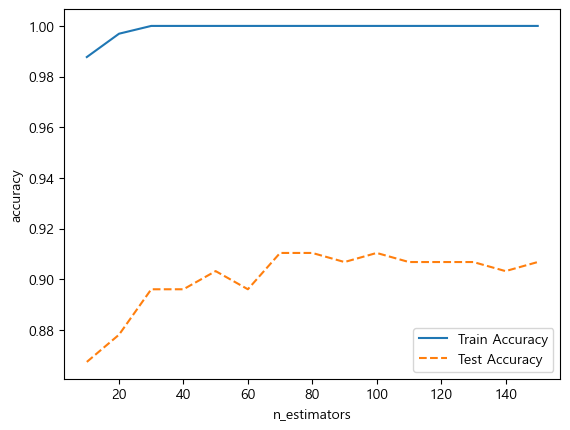

In [18]:
# 모델 정확도 그래프 확인
plt.plot(para_n_tree, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_n_tree, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.xlabel("n_estimators"); plt.ylabel("accuracy")
plt.legend()

#### n_estimators: 트리의 개수 변경 시 모델의 oob error 변화

In [19]:
# error 저장 리스트
oob_error = []

for v_n_estimator in range(5, 121):
    rf = RandomForestClassifier(n_estimators = v_n_estimator, oob_score = True, random_state= 1234)
    rf.fit(df_train_x, df_train_y)
    oob_error.append(1 - rf.oob_score_)

c:\Users\User\.conda\envs\bigdata_env\lib\site-packages\sklearn\ensemble\_forest.py:583: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\User\.conda\envs\bigdata_env\lib\site-packages\sklearn\ensemble\_forest.py:583: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\User\.conda\envs\bigdata_env\lib\site-packages\sklearn\ensemble\_forest.py:583: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\User\.conda\envs\bigdata_env\lib\site-packages\sklearn\ensemble\_forest.py:583: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\User\.conda\envs\bigdata_env\lib\site-packages\sklearn\ensemble\_forest.py:

Text(0.5, 0, 'n_estimators')

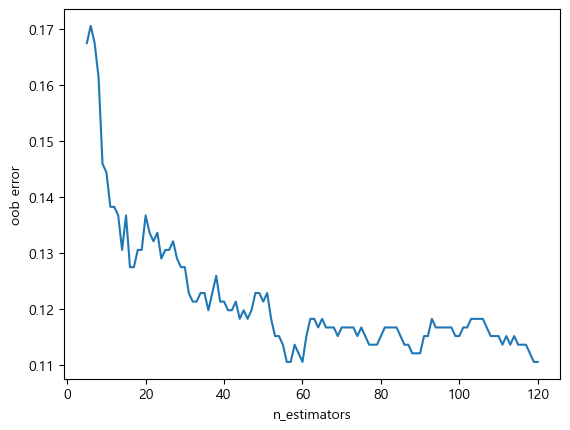

In [20]:
# 그래프로 표현
plt.plot(range(5, 121), oob_error)
plt.ylabel("oob error")
plt.xlabel("n_estimators")

# 깊이

### @max_depth(최대 깊이) 조정에 따른 정확도 변화

In [21]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# max_depth: 최대 깊이 변경
para_depth = [depth for depth in range(3, 11)]

for v_max_depth in para_depth:
    rf = RandomForestClassifier(max_depth = v_max_depth, n_estimators=100, random_state=1234)
    rf.fit(df_train_x, df_train_y)
    train_accuracy.append(rf.score(df_train_x, df_train_y))
    test_accuracy.append(rf.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_depth = pd.DataFrame()
df_accuracy_depth["Depth"] = para_depth
df_accuracy_depth["TrainAccuracy"] = train_accuracy
df_accuracy_depth["TestAccuracy"] = test_accuracy


In [22]:
para_depth

[3, 4, 5, 6, 7, 8, 9, 10]

In [23]:
# 모델 정확도 확인
df_accuracy_depth.round(3)

,Depth,TrainAccuracy,TestAccuracy
0,3,0.860,0.860
1,4,0.880,0.875
2,5,0.897,0.882
3,6,0.920,0.910
4,7,0.935,0.910
5,8,0.946,0.903
6,9,0.949,0.907
7,10,0.955,0.907


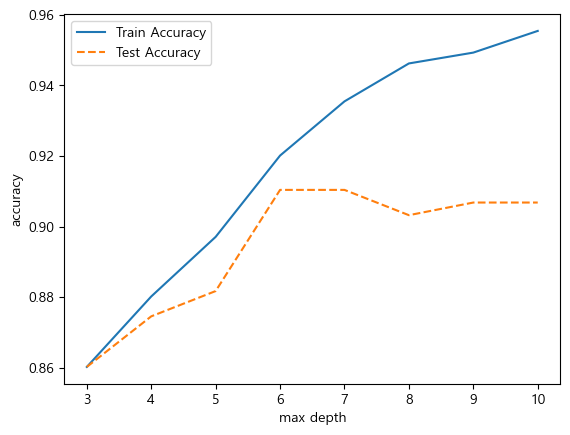

In [24]:
# 모델 정확도 그래프 확인
plt.plot(para_depth, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_depth, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.xlabel("max depth"); plt.ylabel("accuracy")
plt.legend()

In [25]:
# max_depth 지정: 6

### @min_samples_split(분할 노드의 최소 샘플 수) 조정에 따른 정확도 변화

In [26]:
# 참조:적정 자료 수 검토:Train Data 자료 수
print("전체 자료 = ", df_train_x.shape[0],"개")
print("전체 자료의 1% = ", df_train_x.shape[0] * 0.01,"개")

전체 자료 =  651 개
전체 자료의 1% =  6.51 개


In [27]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# min_samples_split: 분할하기 위한 노드의 최소 샘플 수.
para_split = [n_split * 10 for n_split in range(1, 11)]

for v_min_samples_split in para_split:
    rf = RandomForestClassifier(min_samples_split = v_min_samples_split, max_depth=6,
                                n_estimators=100, random_state=1234)
    rf.fit(df_train_x, df_train_y)
    train_accuracy.append(rf.score(df_train_x, df_train_y))
    test_accuracy.append(rf.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_split = pd.DataFrame()
df_accuracy_split["MinSamplesSplit"] = para_split
df_accuracy_split["TrainAccuracy"] = train_accuracy
df_accuracy_split["TestAccuracy"] = test_accuracy

In [28]:
para_split

[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

In [29]:
# 모델 정확도 확인
df_accuracy_split.round(3)

,MinSamplesSplit,TrainAccuracy,TestAccuracy
0,10,0.903,0.907
1,20,0.892,0.896
2,30,0.889,0.900
3,40,0.883,0.896
4,50,0.882,0.896
5,60,0.877,0.900
6,70,0.876,0.900
7,80,0.874,0.900
8,90,0.877,0.896
9,100,0.874,0.896


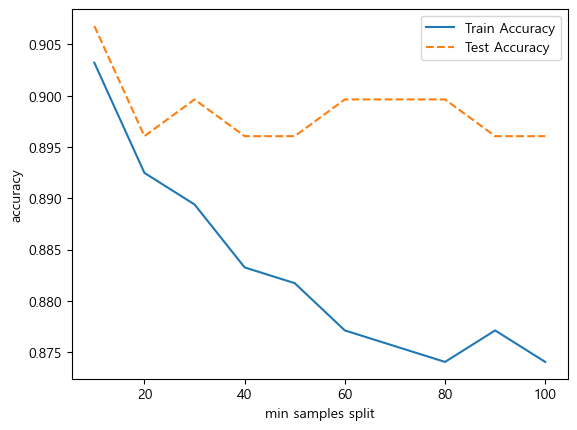

In [30]:
# 모델 정확도 그래프 확인
plt.plot(para_split, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_split, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.xlabel("min samples split"); plt.ylabel("accuracy")
plt.legend()

### @min_samples_leaf(최소 잎사귀 수) 조정에 따른 정확도 변화

In [31]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# min_samples_leaf: 잎사귀 수 제한
para_leaf = [n_leaf * 5 for n_leaf in range(1, 11)]

for v_min_samples_leaf in para_leaf:
    rf = RandomForestClassifier(min_samples_leaf = v_min_samples_leaf,
                                max_depth=6, n_estimators=100, random_state=1234)
    rf.fit(df_train_x, df_train_y)
    train_accuracy.append(rf.score(df_train_x, df_train_y))
    test_accuracy.append(rf.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_leaf = pd.DataFrame()
df_accuracy_leaf["MinSamplesLeaf"] = para_leaf
df_accuracy_leaf["TrainAccuracy"] = train_accuracy
df_accuracy_leaf["TestAccuracy"] = test_accuracy

In [32]:
para_leaf

[5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

In [33]:
# 모델 정확도 확인
df_accuracy_leaf.round(3)

,MinSamplesLeaf,TrainAccuracy,TestAccuracy
0,5,0.903,0.903
1,10,0.888,0.889
2,15,0.849,0.867
3,20,0.840,0.857
4,25,0.814,0.842
5,30,0.791,0.842
6,35,0.791,0.842
7,40,0.791,0.842
8,45,0.791,0.842
9,50,0.791,0.842


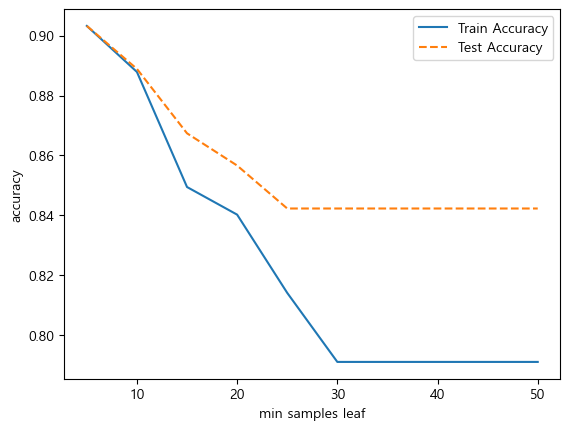

In [34]:
# 모델 정확도 그래프 확인
plt.plot(para_leaf, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_leaf, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.xlabel("min samples leaf"); plt.ylabel("accuracy")
plt.legend()

## 최종 모델

### 파라미터 튜닝 결과 반영한 최종 모델

In [35]:
# 최종 모델 (위 튜닝 결과를 반영하여 파라미터 조정)
rf_final = RandomForestClassifier(min_samples_leaf=20, max_depth=6, n_estimators=100,
                                  random_state=1234)
rf_final.fit(df_train_x, df_train_y)
# 평가
y_pred = rf_final.predict(df_test_x)

# train 데이터 정확도
print("Accuracy on training set: {:.3f}".format(rf_final.score(df_train_x, df_train_y)))
# test 데이터 정확도
print("Accuracy on test set: {:.3f}\n".format(rf_final.score(df_test_x, df_test_y)))

# confusion matrix (0=Active, 1=Churned)
print("Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)))

# 목표변수의 빈도 불균형(Active 750건 vs Churned 180건) : f1 score로 모델 평가
print(classification_report(df_test_y, y_pred, target_names=["Active", "Churned"], digits=3))

Accuracy on training set: 0.840
Accuracy on test set: 0.857

Confusion matrix: 
[[231   4]
 [ 36   8]]
              precision    recall  f1-score   support

      Active      0.865     0.983     0.920       235
     Churned      0.667     0.182     0.286        44

    accuracy                          0.857       279
   macro avg      0.766     0.582     0.603       279
weighted avg      0.834     0.857     0.820       279



#### 설명변수 중요도

In [36]:
rf_final

RandomForestClassifier(max_depth=6, min_samples_leaf=20, random_state=1234)

In [37]:
# 변수명
v_feature_names = df_train_x.columns
# tree.feature_importances_로 설명변수 중요도 확인 및 테이블로 저장
df_importance = pd.DataFrame()
df_importance ["Feature"] = v_feature_names
df_importance ["Importance"] = rf_final.feature_importances_
# df_feature_importance의 테이블을 중요도별로 정렬
df_importance .sort_values("Importance", ascending=False, inplace = True)
df_importance .round(3)

,Feature,Importance
17,HANDSET_ASAD90,0.288
2,DROPPED_CALLS,0.113
8,TOTAL_CALLS_TIME,0.085
4,PEAK_CALLS_TIME,0.076
1,SERVICE_DURATION,0.069
3,PEAK_CALLS_NO,0.058
26,HANDSET_WC95,0.050
7,TOTAL_CALLS_NO,0.044
0,AGE,0.042
16,HANDSET_ASAD170,0.036


Text(0, 0.5, '설명변수')

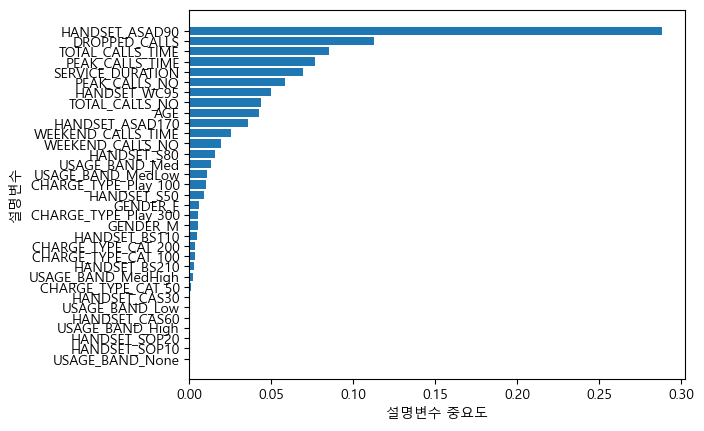

In [38]:
# 설명변수 중요도 그래프
# 중요도가 높은 변수를 상위에 그림 
df_importance .sort_values("Importance", ascending=True, inplace = True)
coordinates = range(len(df_importance ))
plt.barh(y = coordinates, width = df_importance ["Importance"])
plt.yticks(coordinates, df_importance ["Feature"])
plt.xlabel("설명변수 중요도")
plt.ylabel("설명변수")

#### GridSearchCV를 이용한 최적 parameter 찾기

In [ ]:
estimator = RandomForestClassifier(n_estimators=100, random_state=1234)
# 구하고자 하는 parameter와 범위
param_grid = {"max_depth": para_depth,
              "min_samples_leaf": para_leaf}
# 정확도가 높은 최적 parameter 찾기
grid_rf = GridSearchCV(estimator, param_grid, scoring="accuracy", n_jobs=-1)
grid_rf.fit(df_train_x, df_train_y)
print("best estimator model: \n{}".format(grid_rf.best_estimator_))
print("\nbest parameter: \n{}".format(grid_rf.best_params_))
print("\nbest score: \n{}".format(grid_rf.best_score_.round(3)))

best estimator model: 
RandomForestClassifier(max_depth=8, min_samples_leaf=5, random_state=1234)

best parameter: 
{'max_depth': 8, 'min_samples_leaf': 5}

best score: 
0.873


# 실습

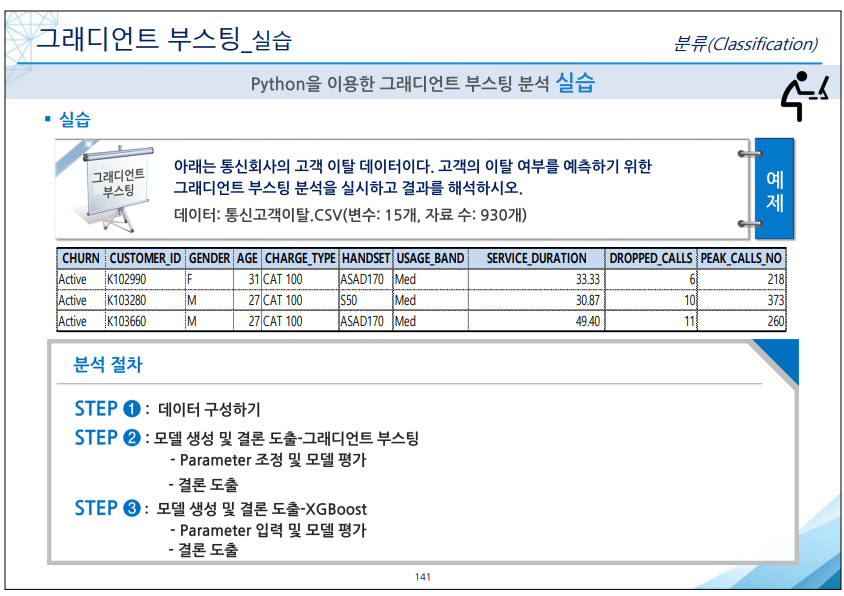

#### 패키지 불러오기

In [ ]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 데이터 분할:train, test
from sklearn.model_selection import train_test_split
# 분류 Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
# 최적 모델, 파라미터 탐색
from sklearn.model_selection import GridSearchCV

# 분류모델 평가 함수
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

#### 그래프 옵션 지정

In [ ]:
# 그래프 한글폰트 적용:맑은 고딕
matplotlib.rc("font", family = "Malgun Gothic")
# 그래프 (-) 기호 표시
matplotlib.rc("axes", unicode_minus = False)

### 데이터 구성하기

In [ ]:
# 데이터 불러오기
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\통신고객이탈.csv", encoding="cp949")
df_raw.head()

,CHURN,CUSTOMER_ID,GENDER,AGE,CHARGE_TYPE,HANDSET,USAGE_BAND,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,Active,K102990,F,31,CAT 100,ASAD170,Med,33.33,6,218,379.8,9,21.6,366,632.4
1,Active,K103280,M,27,CAT 100,S50,Med,30.87,10,373,656.4,11,28.0,411,810.4
2,Active,K103660,M,27,CAT 100,ASAD170,Med,49.40,11,260,582.0,0,0.0,265,614.1
3,Active,K103730,M,61,CAT 100,ASAD170,Med,48.60,1,294,661.8,14,101.5,326,844.0
4,Active,K104560,F,52,CAT 100,S50,Med,56.03,0,221,555.6,7,25.0,274,673.0


In [ ]:
# Data 구조 확인
print("Data 구조:", df_raw.shape)
print()
print("변수 : ", df_raw.columns)

Data 구조: (930, 15)

변수 :  Index(['CHURN', 'CUSTOMER_ID', 'GENDER', 'AGE', 'CHARGE_TYPE', 'HANDSET',
       'USAGE_BAND', 'SERVICE_DURATION', 'DROPPED_CALLS', 'PEAK_CALLS_NO',
       'PEAK_CALLS_TIME', 'WEEKEND_CALLS_NO', 'WEEKEND_CALLS_TIME',
       'TOTAL_CALLS_NO', 'TOTAL_CALLS_TIME'],
      dtype='object')


#### 결측치 처리

In [ ]:
# 결측치 확인
df_raw.isnull().sum(axis = 0)

CHURN                 0
CUSTOMER_ID           0
GENDER                0
AGE                   0
CHARGE_TYPE           0
HANDSET               0
USAGE_BAND            0
SERVICE_DURATION      0
DROPPED_CALLS         0
PEAK_CALLS_NO         0
PEAK_CALLS_TIME       0
WEEKEND_CALLS_NO      0
WEEKEND_CALLS_TIME    0
TOTAL_CALLS_NO        0
TOTAL_CALLS_TIME      0
dtype: int64

In [ ]:
# USAGE_BAND 변수의 결측치는 Other로 입력
df_raw["USAGE_BAND"].fillna("Other", inplace=True)

# 숫자형 변수의 결측치는 해당 변수의 평균값 입력
df_raw.fillna(df_raw.mean(numeric_only=True), inplace=True)

In [ ]:
# 결측치 재확인
df_raw.isnull().sum()

CHURN                 0
CUSTOMER_ID           0
GENDER                0
AGE                   0
CHARGE_TYPE           0
HANDSET               0
USAGE_BAND            0
SERVICE_DURATION      0
DROPPED_CALLS         0
PEAK_CALLS_NO         0
PEAK_CALLS_TIME       0
WEEKEND_CALLS_NO      0
WEEKEND_CALLS_TIME    0
TOTAL_CALLS_NO        0
TOTAL_CALLS_TIME      0
dtype: int64

#### 목표변수 인코딩 및 불필요 변수 제거

In [ ]:
# 목표변수 인코딩: Active=0, Churned=1
df_raw["CHURN"] = df_raw["CHURN"].map({"Active": 0, "Churned": 1})

# 분석에 불필요한 변수 제거 (고객 ID)
df_raw = df_raw.drop("CUSTOMER_ID", axis=1)

df_raw.head()

,CHURN,GENDER,AGE,CHARGE_TYPE,HANDSET,USAGE_BAND,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,0,F,31,CAT 100,ASAD170,Med,33.33,6,218,379.8,9,21.6,366,632.4
1,0,M,27,CAT 100,S50,Med,30.87,10,373,656.4,11,28.0,411,810.4
2,0,M,27,CAT 100,ASAD170,Med,49.40,11,260,582.0,0,0.0,265,614.1
3,0,M,61,CAT 100,ASAD170,Med,48.60,1,294,661.8,14,101.5,326,844.0
4,0,F,52,CAT 100,S50,Med,56.03,0,221,555.6,7,25.0,274,673.0


#### 범주형 설명변수 더미 변환

In [ ]:
# get_dummies: 데이터의 문자형 변수에 대한 더미변수 생성
df_raw_dummy = pd.get_dummies(df_raw)
df_raw_dummy.head()

,CHURN,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME,...,HANDSET_S80,HANDSET_SOP10,HANDSET_SOP20,HANDSET_WC95,USAGE_BAND_High,USAGE_BAND_Low,USAGE_BAND_Med,USAGE_BAND_MedHigh,USAGE_BAND_MedLow,USAGE_BAND_None
0,0,31,33.33,6,218,379.8,9,21.6,366,632.4,...,0,0,0,0,0,0,1,0,0,0
1,0,27,30.87,10,373,656.4,11,28.0,411,810.4,...,0,0,0,0,0,0,1,0,0,0
2,0,27,49.40,11,260,582.0,0,0.0,265,614.1,...,0,0,0,0,0,0,1,0,0,0
3,0,61,48.60,1,294,661.8,14,101.5,326,844.0,...,0,0,0,0,0,0,1,0,0,0
4,0,52,56.03,0,221,555.6,7,25.0,274,673.0,...,0,0,0,0,0,0,1,0,0,0


#### 데이터 분리: 목표변수 vs. 설명변수

In [ ]:
# 설명변수, 목표변수 데이터 구분
df_raw_x = df_raw_dummy.drop("CHURN", axis=1, inplace=False)
df_raw_y = df_raw_dummy["CHURN"]

#### 데이터 분할

In [ ]:
# 데이터 분할 train_test_split(X: 설명변수, Y: 목표변수, test_size = test 데이터 비율)
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(
    df_raw_x, df_raw_y, test_size=0.3, random_state=1234)

print("분할 전 설명변수 데이터 :", df_raw_x.shape)
print("분할 후 설명변수 데이터 :Train", df_train_x.shape, "  Test", df_test_x.shape)

분할 전 설명변수 데이터 : (930, 33)
분할 후 설명변수 데이터 :Train (651, 33)   Test (279, 33)


In [ ]:
display(df_raw.head(10))
display(df_raw_x.head(10))

,CHURN,GENDER,AGE,CHARGE_TYPE,HANDSET,USAGE_BAND,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,0,F,31,CAT 100,ASAD170,Med,33.33,6,218,379.8,9,21.6,366,632.4
1,0,M,27,CAT 100,S50,Med,30.87,10,373,656.4,11,28.0,411,810.4
2,0,M,27,CAT 100,ASAD170,Med,49.40,11,260,582.0,0,0.0,265,614.1
3,0,M,61,CAT 100,ASAD170,Med,48.60,1,294,661.8,14,101.5,326,844.0
4,0,F,52,CAT 100,S50,Med,56.03,0,221,555.6,7,25.0,274,673.0
5,0,M,51,CAT 100,S80,Med,49.43,3,289,486.6,1,31.8,427,903.3
6,0,F,30,CAT 100,ASAD170,Med,32.30,6,427,729.6,12,52.8,490,907.2
7,0,M,36,CAT 100,ASAD170,Med,54.87,2,522,801.6,0,0.0,558,884.7
8,0,F,43,CAT 100,S50,Med,11.23,0,156,516.6,8,84.0,362,987.6
9,0,F,50,CAT 100,ASAD170,Med,49.97,0,136,466.2,13,31.8,186,632.7


,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME,GENDER_F,...,HANDSET_S80,HANDSET_SOP10,HANDSET_SOP20,HANDSET_WC95,USAGE_BAND_High,USAGE_BAND_Low,USAGE_BAND_Med,USAGE_BAND_MedHigh,USAGE_BAND_MedLow,USAGE_BAND_None
0,31,33.33,6,218,379.8,9,21.6,366,632.4,1,...,0,0,0,0,0,0,1,0,0,0
1,27,30.87,10,373,656.4,11,28.0,411,810.4,0,...,0,0,0,0,0,0,1,0,0,0
2,27,49.40,11,260,582.0,0,0.0,265,614.1,0,...,0,0,0,0,0,0,1,0,0,0
3,61,48.60,1,294,661.8,14,101.5,326,844.0,0,...,0,0,0,0,0,0,1,0,0,0
4,52,56.03,0,221,555.6,7,25.0,274,673.0,1,...,0,0,0,0,0,0,1,0,0,0
5,51,49.43,3,289,486.6,1,31.8,427,903.3,0,...,1,0,0,0,0,0,1,0,0,0
6,30,32.30,6,427,729.6,12,52.8,490,907.2,1,...,0,0,0,0,0,0,1,0,0,0
7,36,54.87,2,522,801.6,0,0.0,558,884.7,0,...,0,0,0,0,0,0,1,0,0,0
8,43,11.23,0,156,516.6,8,84.0,362,987.6,1,...,0,0,0,0,0,0,1,0,0,0
9,50,49.97,0,136,466.2,13,31.8,186,632.7,1,...,0,0,0,0,0,0,1,0,0,0


In [ ]:
# Data 구조 확인
print("Data 구조:", df_raw_x.columns)
print()
print("변수 : ", df_train_x.columns)

Data 구조: Index(['AGE', 'SERVICE_DURATION', 'DROPPED_CALLS', 'PEAK_CALLS_NO',
       'PEAK_CALLS_TIME', 'WEEKEND_CALLS_NO', 'WEEKEND_CALLS_TIME',
       'TOTAL_CALLS_NO', 'TOTAL_CALLS_TIME', 'GENDER_F', 'GENDER_M',
       'CHARGE_TYPE_CAT 100', 'CHARGE_TYPE_CAT 200', 'CHARGE_TYPE_CAT 50',
       'CHARGE_TYPE_Play 100', 'CHARGE_TYPE_Play 300', 'HANDSET_ASAD170',
       'HANDSET_ASAD90', 'HANDSET_BS110', 'HANDSET_BS210', 'HANDSET_CAS30',
       'HANDSET_CAS60', 'HANDSET_S50', 'HANDSET_S80', 'HANDSET_SOP10',
       'HANDSET_SOP20', 'HANDSET_WC95', 'USAGE_BAND_High', 'USAGE_BAND_Low',
       'USAGE_BAND_Med', 'USAGE_BAND_MedHigh', 'USAGE_BAND_MedLow',
       'USAGE_BAND_None'],
      dtype='object')

변수 :  Index(['AGE', 'SERVICE_DURATION', 'DROPPED_CALLS', 'PEAK_CALLS_NO',
       'PEAK_CALLS_TIME', 'WEEKEND_CALLS_NO', 'WEEKEND_CALLS_TIME',
       'TOTAL_CALLS_NO', 'TOTAL_CALLS_TIME', 'GENDER_F', 'GENDER_M',
       'CHARGE_TYPE_CAT 100', 'CHARGE_TYPE_CAT 200', 'CHARGE_TYPE_CAT 50',
       'C

## 모델 생성

### 기본 옵션 모델

In [ ]:
# 그래디언트 부스팅 모델 생성: GradientBoostingClassifier
gb_uncust = GradientBoostingClassifier(random_state=1234)
gb_uncust.fit(df_train_x, df_train_y)

# train 모델 정확도
print("Accuracy on training set: {:.3f}".format(gb_uncust.score(df_train_x, df_train_y)))
# test 모델 정확도
print("Accuracy on test set: {:.3f}".format(gb_uncust.score(df_test_x, df_test_y)))

Accuracy on training set: 0.971
Accuracy on test set: 0.885


In [ ]:
# 실행옵션 확인
print(gb_uncust.get_params().keys())
print(gb_uncust.get_params().values())

dict_keys(['ccp_alpha', 'criterion', 'init', 'learning_rate', 'loss', 'max_depth', 'max_features', 'max_leaf_nodes', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'n_estimators', 'n_iter_no_change', 'random_state', 'subsample', 'tol', 'validation_fraction', 'verbose', 'warm_start'])
dict_values([0.0, 'friedman_mse', None, 0.1, 'log_loss', 3, None, None, 0.0, 1, 2, 0.0, 100, None, 1234, 1.0, 0.0001, 0.1, 0, False])


#### @learning_rate(학습률) 변화에 따른 모델 성능

In [ ]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# learning_rate 학습률 변경
para_lr = [lr * 0.1 for lr in range(1, 10)]

for v_learning_rate in para_lr:
    gb = GradientBoostingClassifier(learning_rate=v_learning_rate, random_state=1234)
    gb.fit(df_train_x, df_train_y)
    train_accuracy.append(gb.score(df_train_x, df_train_y))
    test_accuracy.append(gb.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_lr = pd.DataFrame()
df_accuracy_lr["LearningRate"] = para_lr
df_accuracy_lr["TrainAccuracy"] = train_accuracy
df_accuracy_lr["TestAccuracy"] = test_accuracy

In [ ]:
para_lr

[0.1,
 0.2,
 0.30000000000000004,
 0.4,
 0.5,
 0.6000000000000001,
 0.7000000000000001,
 0.8,
 0.9]

In [ ]:
# LearningRate별 정확도
df_accuracy_lr.round(3)

,LearningRate,TrainAccuracy,TestAccuracy
0,0.1,0.971,0.885
1,0.2,0.998,0.889
2,0.3,1.000,0.889
3,0.4,1.000,0.860
4,0.5,1.000,0.878
5,0.6,1.000,0.882
6,0.7,1.000,0.875
7,0.8,1.000,0.885
8,0.9,1.000,0.849


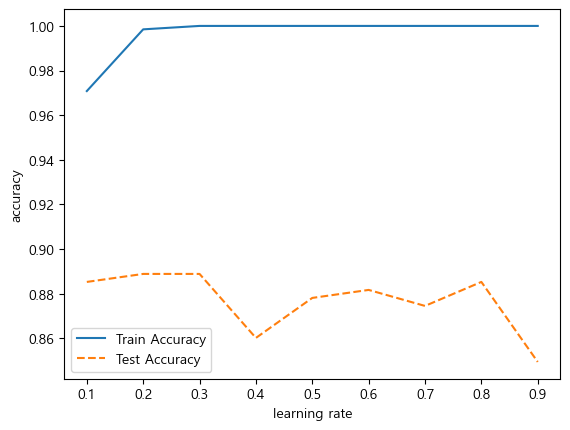

In [ ]:
# LearningRate별 정확도 그래프 확인
plt.plot(para_lr, train_accuracy, linestyle="-", label="Train Accuracy")
plt.plot(para_lr, test_accuracy, linestyle="--", label="Test Accuracy")
plt.ylabel("accuracy"); plt.xlabel("learning rate")
plt.legend()

#### @n_estimators: 트리의 개수 변경에 따른 모델 성능

In [ ]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# n_estimators: 트리 수 변경
para_n_tree = [n_tree * 10 for n_tree in range(1, 16)]

for v_n_estimators in para_n_tree:
    gb = GradientBoostingClassifier(n_estimators=v_n_estimators, learning_rate=0.1, random_state=1234)
    gb.fit(df_train_x, df_train_y)
    train_accuracy.append(gb.score(df_train_x, df_train_y))
    test_accuracy.append(gb.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_n = pd.DataFrame()
df_accuracy_n["Estimators"] = para_n_tree
df_accuracy_n["TrainAccuracy"] = train_accuracy
df_accuracy_n["TestAccuracy"] = test_accuracy

In [ ]:
para_n_tree

[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]

In [ ]:
# n_estimators별 정확도
df_accuracy_n.round(3)

,Estimators,TrainAccuracy,TestAccuracy
0,10,0.879,0.892
1,20,0.916,0.900
2,30,0.931,0.914
3,40,0.935,0.914
4,50,0.943,0.900
5,60,0.951,0.896
6,70,0.952,0.892
7,80,0.957,0.889
8,90,0.963,0.889
9,100,0.971,0.885


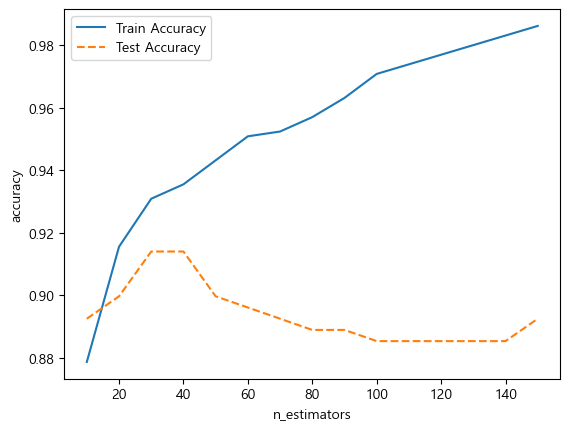

In [ ]:
# 정확도를 그래프 확인
plt.plot(para_n_tree, train_accuracy, linestyle="-", label="Train Accuracy")
plt.plot(para_n_tree, test_accuracy, linestyle="--", label="Test Accuracy")
plt.ylabel("accuracy"); plt.xlabel("n_estimators")
plt.legend()

#### @max_depth: 최대 깊이 변경에 따른 모델 성능

In [ ]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# max_depth: 최대 깊이 변경. 1~10
para_depth = [depth for depth in range(1, 11)]

for v_max_depth in para_depth:
    gb = GradientBoostingClassifier(max_depth=v_max_depth,
                            n_estimators=100, learning_rate=0.1, random_state=1234)
    gb.fit(df_train_x, df_train_y)
    train_accuracy.append(gb.score(df_train_x, df_train_y))
    test_accuracy.append(gb.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_depth = pd.DataFrame()
df_accuracy_depth["Depth"] = para_depth
df_accuracy_depth["TrainAccuracy"] = train_accuracy
df_accuracy_depth["TestAccuracy"] = test_accuracy

In [ ]:
para_depth

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [ ]:
# max_depth별 정확도
df_accuracy_depth.round(3)

,Depth,TrainAccuracy,TestAccuracy
0,1,0.899,0.918
1,2,0.935,0.914
2,3,0.971,0.885
3,4,0.992,0.882
4,5,1.000,0.875
5,6,1.000,0.878
6,7,1.000,0.882
7,8,1.000,0.882
8,9,1.000,0.885
9,10,1.000,0.892


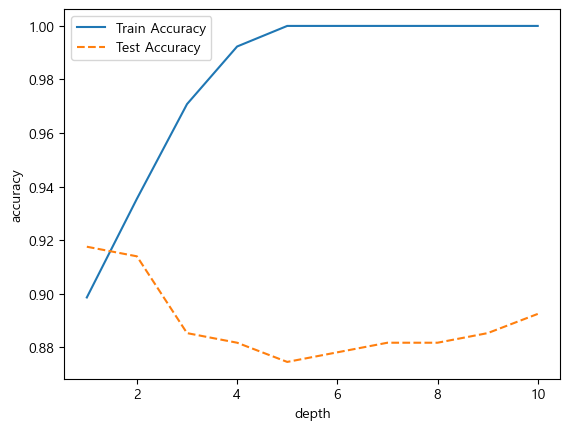

In [ ]:
# 정확도를 그래프 확인
plt.plot(para_depth, train_accuracy, linestyle="-", label="Train Accuracy")
plt.plot(para_depth, test_accuracy, linestyle="--", label="Test Accuracy")
plt.ylabel("accuracy"); plt.xlabel("depth")
plt.legend()

#### @min_samples_split: 분리 노드의 최소 샘플 수 변경에 따른 모델 성능

In [ ]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# min_samples_split: 분할하기 위한 노드의 최소 샘플 수. 20~100
para_split = [n_split * 10 for n_split in range(2, 11)]

for v_min_samples_split in para_split:
    gb = GradientBoostingClassifier(min_samples_split=v_min_samples_split,
                                    max_depth=3, n_estimators=100, learning_rate=0.1, random_state=1234)
    gb.fit(df_train_x, df_train_y)
    train_accuracy.append(gb.score(df_train_x, df_train_y))
    test_accuracy.append(gb.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_split = pd.DataFrame()
df_accuracy_split["MinSamplesSplit"] = para_split
df_accuracy_split["TrainAccuracy"] = train_accuracy
df_accuracy_split["TestAccuracy"] = test_accuracy

In [ ]:
para_split

[20, 30, 40, 50, 60, 70, 80, 90, 100]

In [ ]:
# min_samples_split별 정확도
df_accuracy_split.round(3)

,MinSamplesSplit,TrainAccuracy,TestAccuracy
0,20,0.959,0.896
1,30,0.948,0.885
2,40,0.951,0.900
3,50,0.945,0.896
4,60,0.946,0.896
5,70,0.942,0.896
6,80,0.939,0.903
7,90,0.934,0.900
8,100,0.934,0.907


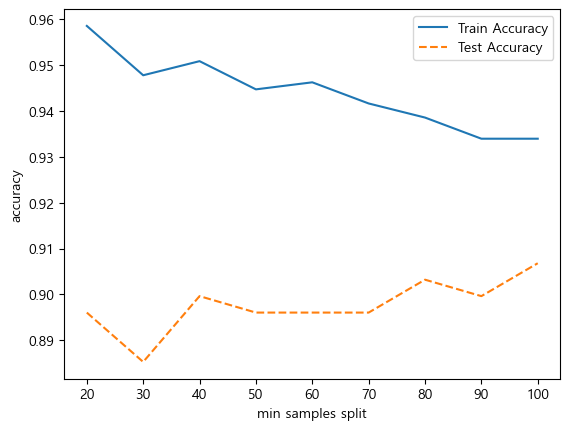

In [ ]:
# 정확도를 그래프 확인
plt.plot(para_split, train_accuracy, linestyle="-", label="Train Accuracy")
plt.plot(para_split, test_accuracy, linestyle="--", label="Test Accuracy")
plt.ylabel("accuracy"); plt.xlabel("min samples split")
plt.legend()

#### @min_samples_leaf: leaf 수 변경에 따른 모델 성능

In [ ]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# min_samples_leaf: 잎사귀 노드 최소 자료 수. 5~50
para_leaf = [n_leaf * 5 for n_leaf in range(1, 11)]

for v_min_samples_leaf in para_leaf:
    gb = GradientBoostingClassifier(min_samples_leaf=v_min_samples_leaf,
                                     max_depth=3, n_estimators=100, learning_rate=0.1, random_state=1234)
    gb.fit(df_train_x, df_train_y)
    train_accuracy.append(gb.score(df_train_x, df_train_y))
    test_accuracy.append(gb.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_leaf = pd.DataFrame()
df_accuracy_leaf["MinSamplesLeaf"] = para_leaf
df_accuracy_leaf["TrainAccuracy"] = train_accuracy
df_accuracy_leaf["TestAccuracy"] = test_accuracy

In [ ]:
para_leaf

[5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

In [ ]:
# min_samples_leaf별 정확도
df_accuracy_leaf.round(3)

,MinSamplesLeaf,TrainAccuracy,TestAccuracy
0,5,0.962,0.892
1,10,0.957,0.882
2,15,0.943,0.892
3,20,0.939,0.896
4,25,0.923,0.882
5,30,0.932,0.885
6,35,0.922,0.882
7,40,0.923,0.882
8,45,0.909,0.846
9,50,0.899,0.835


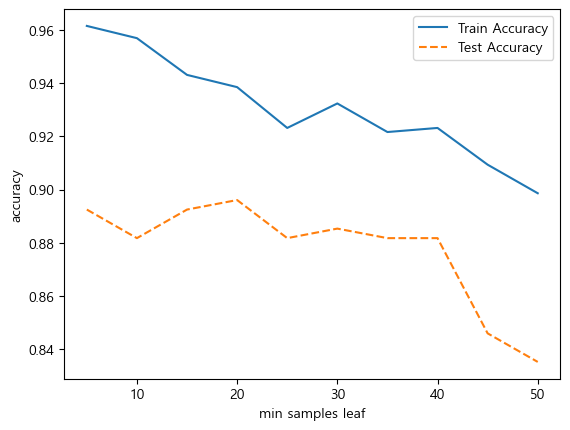

In [ ]:
# 정확도를 그래프 확인
plt.plot(para_leaf, train_accuracy, linestyle="-", label="Train Accuracy")
plt.plot(para_leaf, test_accuracy, linestyle="--", label="Test Accuracy")
plt.ylabel("accuracy"); plt.xlabel("min samples leaf")
plt.legend()

## 결론 도출

#### 최종 모델 선택

In [ ]:
# 최종 모델 (파라미터 튜닝 결과 반영)
gb_final = GradientBoostingClassifier(min_samples_leaf=15, max_depth=3, n_estimators=100, learning_rate=0.1,
                                      random_state=1234)
gb_final.fit(df_train_x, df_train_y)
# 예측
y_pred = gb_final.predict(df_test_x)

# train 모델 정확도
print("Train Accuracy: {:.3f}".format(gb_final.score(df_train_x, df_train_y)))
# test 모델 정확도
print("Test Accuracy: {:.3f}\n".format(gb_final.score(df_test_x, df_test_y)))
# confusion matrix
print("Test Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)))

# 목표변수의 빈도 불균형 : f1 score로 모델 평가
print(classification_report(df_test_y, y_pred, digits=3))

Train Accuracy: 0.943
Test Accuracy: 0.892

Test Confusion matrix: 
[[220  15]
 [ 15  29]]
              precision    recall  f1-score   support

           0      0.936     0.936     0.936       235
           1      0.659     0.659     0.659        44

    accuracy                          0.892       279
   macro avg      0.798     0.798     0.798       279
weighted avg      0.892     0.892     0.892       279



#### 설명변수 중요도

In [ ]:
# 변수명
v_feature_name = df_train_x.columns
# feature_importances_로 설명변수 중요도 확인 및 테이블로 저장
df_importance = pd.DataFrame()
df_importance["Feature"] = v_feature_name
df_importance["Importance"] = gb_final.feature_importances_
# 중요도별로 정렬
df_importance.sort_values("Importance", ascending=False, inplace=True)
df_importance.round(3)

,Feature,Importance
17,HANDSET_ASAD90,0.262
2,DROPPED_CALLS,0.187
20,HANDSET_CAS30,0.123
4,PEAK_CALLS_TIME,0.104
1,SERVICE_DURATION,0.083
8,TOTAL_CALLS_TIME,0.073
0,AGE,0.026
22,HANDSET_S50,0.026
3,PEAK_CALLS_NO,0.018
5,WEEKEND_CALLS_NO,0.017


Text(0, 0.5, '설명변수')

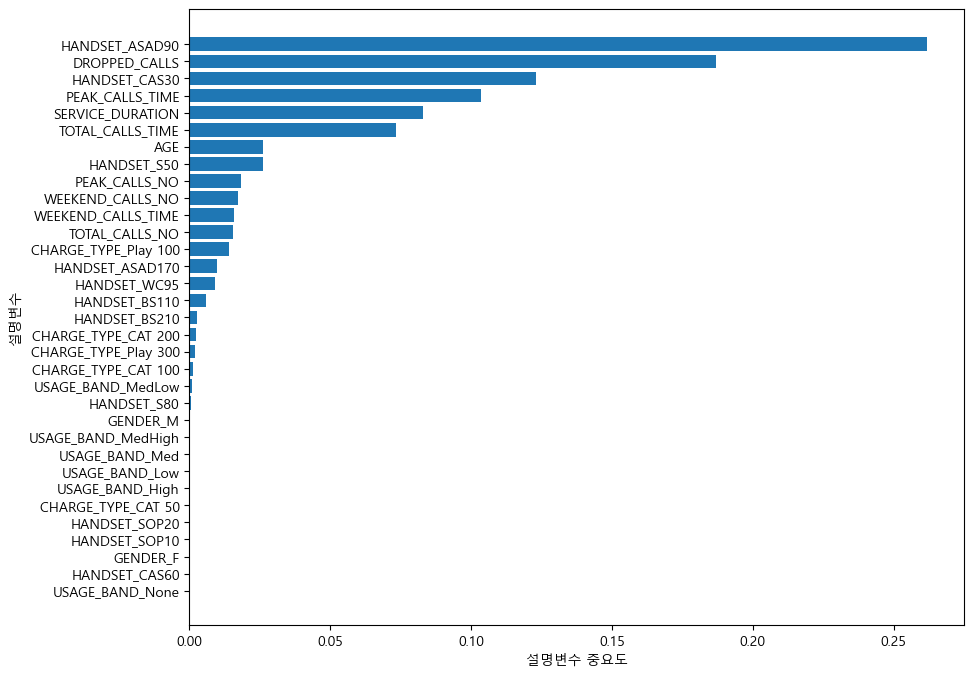

In [ ]:
# 설명변수 중요도 그래프
# 중요도가 높은 변수를 상위에 그림
fig, ax = plt.subplots(figsize=(10, 8))

df_importance.sort_values("Importance", ascending=True, inplace=True)
coordinates = range(len(df_importance))
plt.barh(y=coordinates, width=df_importance["Importance"])
plt.yticks(coordinates, df_importance["Feature"])
plt.xlabel("설명변수 중요도")
plt.ylabel("설명변수")

#### 참조:Grid Search

## @xgboost 실습

### @sklearn Framework 기반의 XGBoost 실습

특징
. 사이킷런의 기본 Estimator를 이용해 만들어 fit()과 predict()만으로 학습과 예측이 가능

. GridSearchCV, Pipeline 등 사이킷런의 유틸리티를 그대로 사용 가능
. 분류 : XGBClassifier / 회귀 : XGBRegressor

eta → learning_rate
sub_sample → subsample
lambda → reg_lambda
alpha → reg_alpha
num_boost_round → n_estimators

In [ ]:
!pip install xgboost

In [ ]:
# xgboost 패키지 불러오기
from xgboost import XGBClassifier

# 변수 중요도 확인: F1 점수 기준
from xgboost import plot_importance

# 분류모델 통합 평가: 혼동행렬, 정확도, 정밀도, 재현율, F1, AUC 등
def eval_class_model(y_test, y_pred):
    confusion = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    F1 = f1_score(y_test, y_pred)
    AUC = roc_auc_score(y_test, y_pred)

    print('오차행렬:\n', confusion, '\n')
    print('정확도: {:.4f}'.format(accuracy))
    print('정밀도: {:.4f}'.format(precision))
    print('재현율: {:.4f}'.format(recall))
    print('F1    : {:.4f}'.format(F1))
    print('AUC   : {:.4f}'.format(AUC))


In [ ]:
# 기본 모델 지정 및 기본 옵션 확인
xgboost_uncust = XGBClassifier(random_state=1234)

xgboost_uncust

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# 모델 적합
xgboost_uncust.fit(df_train_x, df_train_y)

print('\n 모델 생성 및 평가 : Train \n')
# 예측 및 모델 평가:train
xgb_pred_train = xgboost_uncust.predict(df_train_x)
eval_class_model(df_train_y, xgb_pred_train)

print('\n 모델 생성 및 평가 : Test \n')
# 예측 및 모델 평가:test
xgb_pred_test = xgboost_uncust.predict(df_test_x)
eval_class_model(df_test_y, xgb_pred_test)


 모델 생성 및 평가 : Train 

오차행렬:
 [[515   0]
 [  0 136]] 

정확도: 1.0000
정밀도: 1.0000
재현율: 1.0000
F1    : 1.0000
AUC   : 1.0000

 모델 생성 및 평가 : Test 

오차행렬:
 [[219  16]
 [ 20  24]] 

정확도: 0.8710
정밀도: 0.6000
재현율: 0.5455
F1    : 0.5714
AUC   : 0.7387


In [ ]:
# 사용자 모델 생성
xgboost_user = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=1234)
# 모델 적합
xgboost_user.fit(df_train_x, df_train_y)

# 예측 및 모델 평가:Train
xgb_pred_train = xgboost_user.predict(df_train_x)

print('\n 사용자 모델 평가 : Train \n')
eval_class_model(df_train_y, xgb_pred_train)
print('\n', classification_report(df_train_y, xgb_pred_train))

# 예측 및 모델 평가:Test
xgb_pred_test = xgboost_user.predict(df_test_x)

print('\n 사용자 모델 평가 : Test \n')
eval_class_model(df_test_y, xgb_pred_test)
print('\n', classification_report(df_test_y, xgb_pred_test))


 사용자 모델 평가 : Train 

오차행렬:
 [[515   0]
 [  5 131]] 

정확도: 0.9923
정밀도: 1.0000
재현율: 0.9632
F1    : 0.9813
AUC   : 0.9816

               precision    recall  f1-score   support

           0       0.99      1.00      1.00       515
           1       1.00      0.96      0.98       136

    accuracy                           0.99       651
   macro avg       1.00      0.98      0.99       651
weighted avg       0.99      0.99      0.99       651


 사용자 모델 평가 : Test 

오차행렬:
 [[223  12]
 [ 18  26]] 

정확도: 0.8925
정밀도: 0.6842
재현율: 0.5909
F1    : 0.6341
AUC   : 0.7699

               precision    recall  f1-score   support

           0       0.93      0.95      0.94       235
           1       0.68      0.59      0.63        44

    accuracy                           0.89       279
   macro avg       0.80      0.77      0.79       279
weighted avg       0.89      0.89      0.89       279



In [ ]:
# 평가 데이터셋 설정
eval_df = [(df_test_x, df_test_y)]

# 1. 생성자에서 조기 중단 및 평가 지표 설정
xgb_stop = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=1234,
    early_stopping_rounds=150, # 조기 중단 횟수 설정
    eval_metric="logloss"      # 평가 지표 설정
)

# 2. fit() 호출 (eval_set만 전달)
xgb_stop.fit(
    df_train_x, 
    df_train_y,
    eval_set=eval_df, 
    verbose=True
)

[0]	validation_0-logloss:0.41339
[1]	validation_0-logloss:0.38990
[2]	validation_0-logloss:0.37402
[3]	validation_0-logloss:0.36227
[4]	validation_0-logloss:0.34890
[5]	validation_0-logloss:0.33840
[6]	validation_0-logloss:0.32591
[7]	validation_0-logloss:0.31770
[8]	validation_0-logloss:0.31134
[9]	validation_0-logloss:0.30784
[10]	validation_0-logloss:0.30131
[11]	validation_0-logloss:0.29837
[12]	validation_0-logloss:0.29435
[13]	validation_0-logloss:0.29012
[14]	validation_0-logloss:0.28434
[15]	validation_0-logloss:0.28277
[16]	validation_0-logloss:0.27867
[17]	validation_0-logloss:0.27686
[18]	validation_0-logloss:0.27333
[19]	validation_0-logloss:0.27093
[20]	validation_0-logloss:0.26968
[21]	validation_0-logloss:0.26782
[22]	validation_0-logloss:0.26477
[23]	validation_0-logloss:0.26390
[24]	validation_0-logloss:0.26337
[25]	validation_0-logloss:0.26212
[26]	validation_0-logloss:0.26201
[27]	validation_0-logloss:0.26185
[28]	validation_0-logloss:0.25987
[29]	validation_0-loglos

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=150,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# 최적 모델 정보 확인
print("최적 횟수:", xgb_stop.best_iteration)
print("최적 성능(0-LogLoss):", xgb_stop.best_score)

최적 횟수: 34
최적 성능(0-LogLoss): 0.25394196424125876


In [ ]:
# 최적 모델 평가
xgb_pred_stop = xgb_stop.predict(df_test_x)

print('\n 조기 중단 모델 평가 : Test \n')
eval_class_model(df_test_y, xgb_pred_stop)
print('\n', classification_report(df_test_y, xgb_pred_stop))


 조기 중단 모델 평가 : Test 

오차행렬:
 [[224  11]
 [ 19  25]] 

정확도: 0.8925
정밀도: 0.6944
재현율: 0.5682
F1    : 0.6250
AUC   : 0.7607

               precision    recall  f1-score   support

           0       0.92      0.95      0.94       235
           1       0.69      0.57      0.62        44

    accuracy                           0.89       279
   macro avg       0.81      0.76      0.78       279
weighted avg       0.89      0.89      0.89       279



{'AGE': 249.0, 'SERVICE_DURATION': 273.0, 'DROPPED_CALLS': 149.0, 'PEAK_CALLS_NO': 165.0, 'PEAK_CALLS_TIME': 213.0, 'WEEKEND_CALLS_NO': 181.0, 'WEEKEND_CALLS_TIME': 228.0, 'TOTAL_CALLS_NO': 169.0, 'TOTAL_CALLS_TIME': 189.0, 'GENDER_F': 41.0, 'CHARGE_TYPE_CAT 100': 9.0, 'CHARGE_TYPE_CAT 200': 14.0, 'CHARGE_TYPE_Play 100': 26.0, 'CHARGE_TYPE_Play 300': 12.0, 'HANDSET_ASAD170': 23.0, 'HANDSET_ASAD90': 100.0, 'HANDSET_BS110': 44.0, 'HANDSET_BS210': 20.0, 'HANDSET_CAS30': 68.0, 'HANDSET_S50': 48.0, 'HANDSET_S80': 17.0, 'HANDSET_WC95': 25.0, 'USAGE_BAND_Med': 3.0, 'USAGE_BAND_MedHigh': 28.0, 'USAGE_BAND_MedLow': 7.0}


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

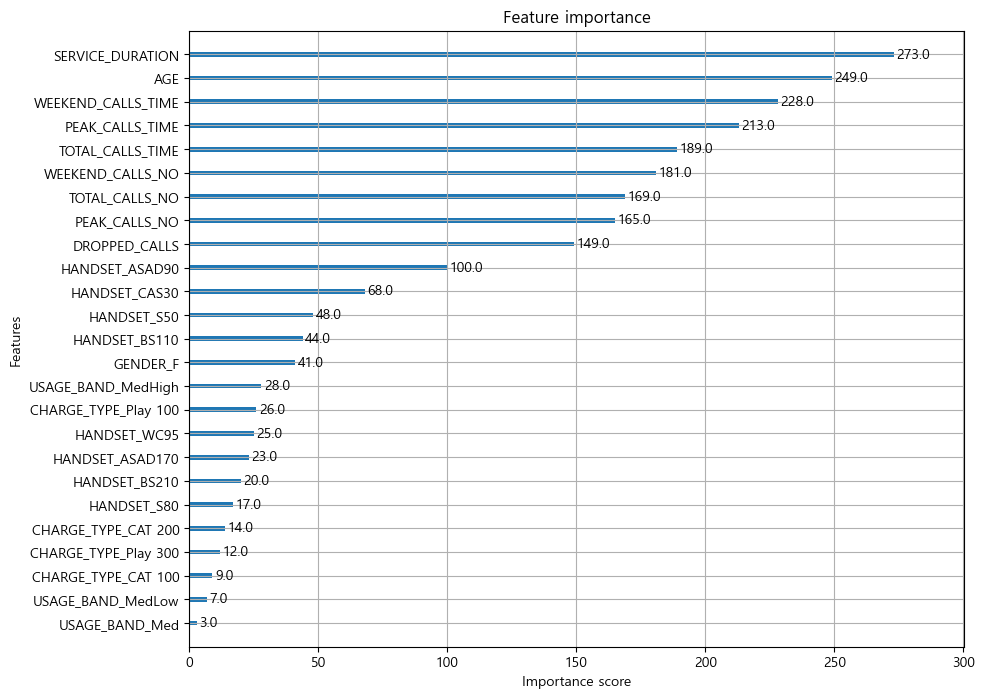

In [ ]:
# 변수 중요도 확인
from xgboost import plot_importance
print(xgb_stop.get_booster().get_fscore())

fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(xgb_stop, ax=ax)

In [ ]:
# importance_type 변경 가능
# plot_importance(xgb_stop, importance_type='gain', ax=ax)

## @LightGBM 실습

In [ ]:
# !pip install lightgbm

### @sklearn Framework 기반의 LightGBM 실습

* 설치 : !pip install lightgbm 또는 conda install lightgbm

* 특징
    - Leaf-wise 분할방식: 최대 손실 값을 가지는 리프 노드를 지속적으로 분할
    - XGBoost 보다 학습 소요시간 및 메모리 등 시스템 자원 사용량이 상대적으로 적다
    - 범주형 설명변수의 자동 변환과 최적 분할 지원

* 모델 : 분류-LGBMClassifier, 예측-LGBMRegressor

In [ ]:
# LightGBM 패키지 불러오기
from lightgbm import LGBMClassifier
from lightgbm import plot_importance

# 분류모델 통합 평가: 혼동행렬, 정확도, 정밀도, 재현율, F1, AUC 등
def eval_class_model(y_test, y_pred):
    confusion = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    F1 = f1_score(y_test, y_pred)
    AUC = roc_auc_score(y_test, y_pred)

    print('오차행렬:\n', confusion, '\n')
    print('정확도: {:.4f}'.format(accuracy))
    print('정밀도: {:.4f}'.format(precision))
    print('재현율: {:.4f}'.format(recall))
    print('F1    : {:.4f}'.format(F1))
    print('AUC   : {:.4f}'.format(AUC))


In [ ]:
# 기본 모델 지정 및 기본 옵션 확인
lgbm_uncust = LGBMClassifier(random_state=1234)

lgbm_uncust.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': -1,
 'num_leaves': 31,
 'objective': None,
 'random_state': 1234,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'silent': 'warn',
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0}

In [ ]:
# 모델 적합
lgbm_uncust.fit(df_train_x, df_train_y)
print('\n 모델 생성 및 평가 : Train \n')
lgbm_pred_train = lgbm_uncust.predict(df_train_x)
eval_class_model(df_train_y, lgbm_pred_train)
print('\n 모델 생성 및 평가 : Test \n')
lgbm_pred_test = lgbm_uncust.predict(df_test_x)
eval_class_model(df_test_y, lgbm_pred_test)


 모델 생성 및 평가 : Train 

오차행렬:
 [[515   0]
 [  0 136]] 

정확도: 1.0000
정밀도: 1.0000
재현율: 1.0000
F1    : 1.0000
AUC   : 1.0000

 모델 생성 및 평가 : Test 

오차행렬:
 [[222  13]
 [ 16  28]] 

정확도: 0.8961
정밀도: 0.6829
재현율: 0.6364
F1    : 0.6588
AUC   : 0.7905


In [ ]:
# 사용자 모델 생성
lgbm_user = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=1234)
lgbm_user.fit(df_train_x, df_train_y)

lgbm_pred_train = lgbm_user.predict(df_train_x)
print('\n 사용자 모델 평가 : Train \n')
eval_class_model(df_train_y, lgbm_pred_train)
print('\n', classification_report(df_train_y, lgbm_pred_train))

lgbm_pred_test = lgbm_user.predict(df_test_x)
print('\n 사용자 모델 평가 : Test \n')
eval_class_model(df_test_y, lgbm_pred_test)
print('\n', classification_report(df_test_y, lgbm_pred_test))


 사용자 모델 평가 : Train 

오차행렬:
 [[515   0]
 [  0 136]] 

정확도: 1.0000
정밀도: 1.0000
재현율: 1.0000
F1    : 1.0000
AUC   : 1.0000

               precision    recall  f1-score   support

           0       1.00      1.00      1.00       515
           1       1.00      1.00      1.00       136

    accuracy                           1.00       651
   macro avg       1.00      1.00      1.00       651
weighted avg       1.00      1.00      1.00       651


 사용자 모델 평가 : Test 

오차행렬:
 [[220  15]
 [ 16  28]] 

정확도: 0.8889
정밀도: 0.6512
재현율: 0.6364
F1    : 0.6437
AUC   : 0.7863

               precision    recall  f1-score   support

           0       0.93      0.94      0.93       235
           1       0.65      0.64      0.64        44

    accuracy                           0.89       279
   macro avg       0.79      0.79      0.79       279
weighted avg       0.89      0.89      0.89       279



In [ ]:
# 조기 중단
eval_df = [(df_test_x, df_test_y)]

lgbm_stop = LGBMClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=1234)
lgbm_stop.fit(df_train_x, df_train_y,
              early_stopping_rounds=200, eval_metric="logloss", eval_set=eval_df, verbose=True)

[1]	valid_0's binary_logloss: 0.408606
[2]	valid_0's binary_logloss: 0.383786
[3]	valid_0's binary_logloss: 0.365006
[4]	valid_0's binary_logloss: 0.350162
[5]	valid_0's binary_logloss: 0.340059
[6]	valid_0's binary_logloss: 0.329908
[7]	valid_0's binary_logloss: 0.317581
[8]	valid_0's binary_logloss: 0.31095
[9]	valid_0's binary_logloss: 0.306121
[10]	valid_0's binary_logloss: 0.299665
[11]	valid_0's binary_logloss: 0.296399
[12]	valid_0's binary_logloss: 0.293549
[13]	valid_0's binary_logloss: 0.291391
[14]	valid_0's binary_logloss: 0.283541
[15]	valid_0's binary_logloss: 0.278398
[16]	valid_0's binary_logloss: 0.273562
[17]	valid_0's binary_logloss: 0.271503
[18]	valid_0's binary_logloss: 0.269755
[19]	valid_0's binary_logloss: 0.26741
[20]	valid_0's binary_logloss: 0.267971
[21]	valid_0's binary_logloss: 0.266232
[22]	valid_0's binary_logloss: 0.263537
[23]	valid_0's binary_logloss: 0.261961
[24]	valid_0's binary_logloss: 0.260545
[25]	valid_0's binary_logloss: 0.259705
[26]	valid_

c:\Users\User\.conda\envs\bigdata_env\lib\site-packages\lightgbm\sklearn.py:726: UserWarning: 'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
  _log_warning("'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. "
c:\Users\User\.conda\envs\bigdata_env\lib\site-packages\lightgbm\sklearn.py:736: UserWarning: 'verbose' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose' argument is deprecated and will be removed in a future release of LightGBM. "


[121]	valid_0's binary_logloss: 0.296953
[122]	valid_0's binary_logloss: 0.297537
[123]	valid_0's binary_logloss: 0.29959
[124]	valid_0's binary_logloss: 0.299967
[125]	valid_0's binary_logloss: 0.300239
[126]	valid_0's binary_logloss: 0.301169
[127]	valid_0's binary_logloss: 0.301304
[128]	valid_0's binary_logloss: 0.30251
[129]	valid_0's binary_logloss: 0.303253
[130]	valid_0's binary_logloss: 0.30454
[131]	valid_0's binary_logloss: 0.304675
[132]	valid_0's binary_logloss: 0.305985
[133]	valid_0's binary_logloss: 0.306812
[134]	valid_0's binary_logloss: 0.308283
[135]	valid_0's binary_logloss: 0.308496
[136]	valid_0's binary_logloss: 0.309655
[137]	valid_0's binary_logloss: 0.311108
[138]	valid_0's binary_logloss: 0.312085
[139]	valid_0's binary_logloss: 0.312406
[140]	valid_0's binary_logloss: 0.313607
[141]	valid_0's binary_logloss: 0.31331
[142]	valid_0's binary_logloss: 0.313164
[143]	valid_0's binary_logloss: 0.314774
[144]	valid_0's binary_logloss: 0.315816
[145]	valid_0's bina

LGBMClassifier(max_depth=6, n_estimators=300, random_state=1234)

In [ ]:
# 최적모델 정보 확인
print("최적 횟수:", lgbm_stop.best_iteration_)
print("최적 성능(0-LogLoss):", lgbm_stop.best_score_)

최적 횟수: 51
최적 성능(0-LogLoss): defaultdict(<class 'collections.OrderedDict'>, {'valid_0': OrderedDict([('binary_logloss', 0.25529353287146606)])})


In [ ]:
# 최적 모델 평가
lgbm_pred_stop = lgbm_stop.predict(df_test_x)

print('\n 조기 중단 모델 평가 : Test \n')
eval_class_model(df_test_y, lgbm_pred_stop)
print('\n', classification_report(df_test_y, lgbm_pred_stop))


 조기 중단 모델 평가 : Test 

오차행렬:
 [[224  11]
 [ 16  28]] 

정확도: 0.9032
정밀도: 0.7179
재현율: 0.6364
F1    : 0.6747
AUC   : 0.7948

               precision    recall  f1-score   support

           0       0.93      0.95      0.94       235
           1       0.72      0.64      0.67        44

    accuracy                           0.90       279
   macro avg       0.83      0.79      0.81       279
weighted avg       0.90      0.90      0.90       279



['AGE', 'SERVICE_DURATION', 'DROPPED_CALLS', 'PEAK_CALLS_NO', 'PEAK_CALLS_TIME', 'WEEKEND_CALLS_NO', 'WEEKEND_CALLS_TIME', 'TOTAL_CALLS_NO', 'TOTAL_CALLS_TIME', 'GENDER_F', 'GENDER_M', 'CHARGE_TYPE_CAT_100', 'CHARGE_TYPE_CAT_200', 'CHARGE_TYPE_CAT_50', 'CHARGE_TYPE_Play_100', 'CHARGE_TYPE_Play_300', 'HANDSET_ASAD170', 'HANDSET_ASAD90', 'HANDSET_BS110', 'HANDSET_BS210', 'HANDSET_CAS30', 'HANDSET_CAS60', 'HANDSET_S50', 'HANDSET_S80', 'HANDSET_SOP10', 'HANDSET_SOP20', 'HANDSET_WC95', 'USAGE_BAND_High', 'USAGE_BAND_Low', 'USAGE_BAND_Med', 'USAGE_BAND_MedHigh', 'USAGE_BAND_MedLow', 'USAGE_BAND_None']
[61 80 39 42 76 39 47 30 67  6  2  5  0  0  7  5 16 28  8  7 20  0  9 11
  0  0 16  0  0  5  2  3  0]


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

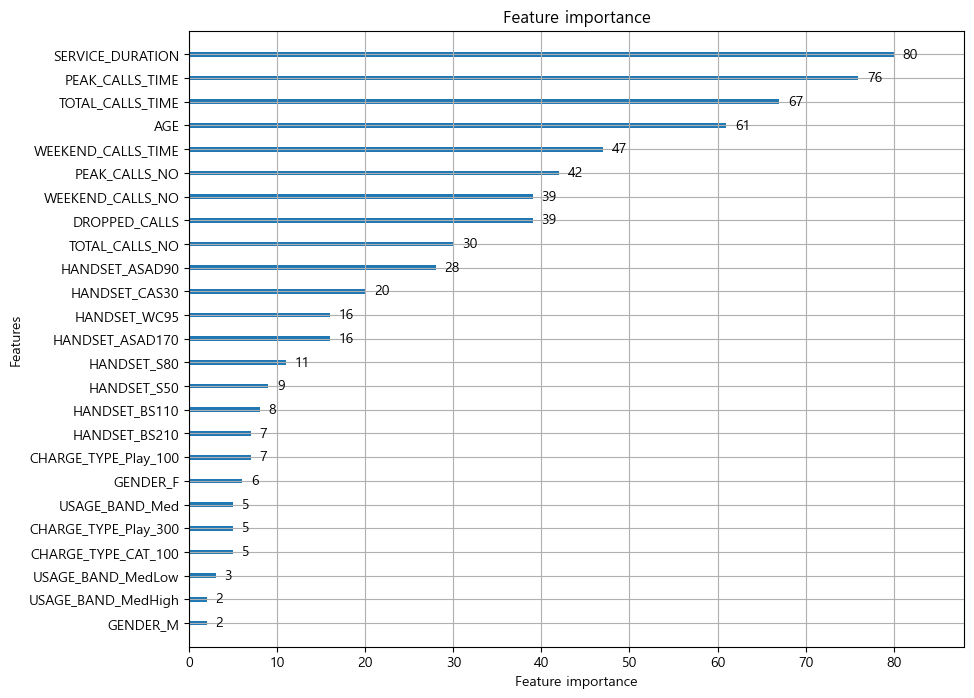

In [ ]:
# 변수 중요도 확인
from lightgbm import plot_importance
print(lgbm_stop.feature_name_)
print(lgbm_stop.feature_importances_)

fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(lgbm_stop, ax=ax)

## @Categorical Boosting 실습

In [ ]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   -- ------------------------------------- 7.1/100.2 MB 39.6 MB/s eta 0:00:03
   ------ --------------------------------- 16.3/100.2 MB 42.6 MB/s eta 0:00:02
   ---------- ----------------------------- 25.2/100.2 MB 41.9 MB/s eta 0:00:02
   ------------- -------------------------- 34.1/100.2 MB 43.3 MB/s eta 0:00:02
   ---------------- ----------------------- 40.4/100.2 MB 40.7 MB/s eta 0:00:02
   ------------------- -------------------- 49.0/100.2 MB 40.5 MB/s eta 0:00:02
   ----------------------- ---------------- 59.0/100.2 MB 41.3 MB/s eta 0:00:01
   -------------------------- ------------- 67.1/100.2 MB 41.5 MB/s eta 0:00:01
   ------------------------------ --------- 76.3/100.2 MB 41.6 MB/s eta 0:00:01
   ---------------------------------- ----- 85.7/100.2 MB 41.7 MB/s eta 0:00:01
   -------------------------------------- - 95.4/100.2 MB 42.3 MB/s eta 0:00:01
   --------------------------------------  100.1/1

In [ ]:
# 패키지 불러오기
from catboost import CatBoostClassifier

# 분류모델 통합 평가: 혼동행렬, 정확도, 정밀도, 재현율, F1, AUC 등
def eval_class_model(y_test, y_pred):
    confusion = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    F1 = f1_score(y_test, y_pred)
    AUC = roc_auc_score(y_test, y_pred)

    print('오차행렬:\n', confusion, '\n')
    print('정확도: {:.4f}'.format(accuracy))
    print('정밀도: {:.4f}'.format(precision))
    print('재현율: {:.4f}'.format(recall))
    print('F1    : {:.4f}'.format(F1))
    print('AUC   : {:.4f}'.format(AUC))


In [ ]:
# 기본 모델 지정 및 기본 옵션 확인
cbc_uncust = CatBoostClassifier(random_state=1234)

cbc_uncust.get_all_params

<bound method CatBoost.get_all_params of CatBoostClassifier(random_state=1234)>

In [ ]:
# 모델 적합
cbc_uncust.fit(df_train_x, df_train_y)

print('\n 모델 생성 및 평가 : Train \n')
cbc_pred_train = cbc_uncust.predict(df_train_x)
eval_class_model(df_train_y, cbc_pred_train)

print('\n 모델 생성 및 평가 : Test \n')
cbc_pred_test = cbc_uncust.predict(df_test_x)
eval_class_model(df_test_y, cbc_pred_test)

Learning rate set to 0.008577
0:	learn: 0.6873585	total: 148ms	remaining: 2m 28s
1:	learn: 0.6806467	total: 150ms	remaining: 1m 14s
2:	learn: 0.6739635	total: 151ms	remaining: 50.3s
3:	learn: 0.6670280	total: 153ms	remaining: 38.1s
4:	learn: 0.6618191	total: 154ms	remaining: 30.7s
5:	learn: 0.6562653	total: 156ms	remaining: 25.8s
6:	learn: 0.6513835	total: 157ms	remaining: 22.3s
7:	learn: 0.6455007	total: 159ms	remaining: 19.7s
8:	learn: 0.6400002	total: 161ms	remaining: 17.7s
9:	learn: 0.6352299	total: 163ms	remaining: 16.1s
10:	learn: 0.6301441	total: 165ms	remaining: 14.8s
11:	learn: 0.6256768	total: 167ms	remaining: 13.7s
12:	learn: 0.6203248	total: 168ms	remaining: 12.8s
13:	learn: 0.6143845	total: 170ms	remaining: 12s
14:	learn: 0.6090188	total: 172ms	remaining: 11.3s
15:	learn: 0.6043022	total: 174ms	remaining: 10.7s
16:	learn: 0.6000636	total: 176ms	remaining: 10.2s
17:	learn: 0.5959679	total: 178ms	remaining: 9.69s
18:	learn: 0.5916362	total: 180ms	remaining: 9.28s
19:	learn: 

In [ ]:
# 사용자 모델 생성
cbc_user = CatBoostClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=1234)
cbc_user.fit(df_train_x, df_train_y)

cbc_pred_train = cbc_user.predict(df_train_x)
print('\n 사용자 모델 평가 : Train \n')
eval_class_model(df_train_y, cbc_pred_train)
print('\n', classification_report(df_train_y, cbc_pred_train))

cbc_pred_test = cbc_user.predict(df_test_x)
print('\n 사용자 모델 평가 : Test \n')
eval_class_model(df_test_y, cbc_pred_test)
print('\n', classification_report(df_test_y, cbc_pred_test))

0:	learn: 0.6297811	total: 1.87ms	remaining: 372ms
1:	learn: 0.5728846	total: 3.47ms	remaining: 344ms
2:	learn: 0.5228817	total: 4.87ms	remaining: 320ms
3:	learn: 0.4773259	total: 6.26ms	remaining: 307ms
4:	learn: 0.4524249	total: 7.71ms	remaining: 301ms
5:	learn: 0.4224169	total: 9.18ms	remaining: 297ms
6:	learn: 0.4058167	total: 10.7ms	remaining: 295ms
7:	learn: 0.3903294	total: 12.2ms	remaining: 293ms
8:	learn: 0.3702705	total: 14ms	remaining: 298ms
9:	learn: 0.3586852	total: 16.1ms	remaining: 306ms
10:	learn: 0.3481512	total: 18.3ms	remaining: 314ms
11:	learn: 0.3383229	total: 20.3ms	remaining: 318ms
12:	learn: 0.3279921	total: 22.9ms	remaining: 329ms
13:	learn: 0.3145170	total: 25ms	remaining: 332ms
14:	learn: 0.3055247	total: 26.9ms	remaining: 332ms
15:	learn: 0.3024558	total: 28.9ms	remaining: 333ms
16:	learn: 0.2939788	total: 31.7ms	remaining: 341ms
17:	learn: 0.2879716	total: 33.7ms	remaining: 340ms
18:	learn: 0.2788955	total: 35.7ms	remaining: 340ms
19:	learn: 0.2750039	total

In [ ]:
# 조기 중단
eval_df = [(df_test_x, df_test_y)]

cbc_stop = CatBoostClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=1234)
cbc_stop.fit(df_train_x, df_train_y,
             early_stopping_rounds=150, eval_set=eval_df, verbose=True)

0:	learn: 0.6297811	test: 0.6304007	best: 0.6304007 (0)	total: 2.75ms	remaining: 823ms
1:	learn: 0.5728846	test: 0.5750094	best: 0.5750094 (1)	total: 5.18ms	remaining: 771ms
2:	learn: 0.5228817	test: 0.5245954	best: 0.5245954 (2)	total: 7.06ms	remaining: 699ms
3:	learn: 0.4773259	test: 0.4776287	best: 0.4776287 (3)	total: 9.34ms	remaining: 691ms
4:	learn: 0.4524249	test: 0.4523382	best: 0.4523382 (4)	total: 11.9ms	remaining: 702ms
5:	learn: 0.4224169	test: 0.4200115	best: 0.4200115 (5)	total: 14.2ms	remaining: 697ms
6:	learn: 0.4058167	test: 0.4034550	best: 0.4034550 (6)	total: 16.5ms	remaining: 689ms
7:	learn: 0.3903294	test: 0.3858054	best: 0.3858054 (7)	total: 18.7ms	remaining: 681ms
8:	learn: 0.3702705	test: 0.3661801	best: 0.3661801 (8)	total: 20.8ms	remaining: 673ms
9:	learn: 0.3586852	test: 0.3592346	best: 0.3592346 (9)	total: 23.2ms	remaining: 672ms
10:	learn: 0.3481512	test: 0.3494074	best: 0.3494074 (10)	total: 25.3ms	remaining: 665ms
11:	learn: 0.3383229	test: 0.3424544	best

CatBoostClassifier(learning_rate=0.1, max_depth=6, n_estimators=300, random_state=1234)

In [ ]:
# 최적모델 정보 확인
print("최적 횟수:", cbc_stop.best_iteration_)
print("최적 성능:", cbc_stop.best_score_)

최적 횟수: 82
최적 성능: {'learn': {'Logloss': 0.021092865328531937}, 'validation': {'Logloss': 0.24890546223910665}}


In [ ]:
# 최적 모델 평가
cbc_pred_stop = cbc_stop.predict(df_test_x)

print('\n 조기 중단 모델 평가 : Test \n')
eval_class_model(df_test_y, cbc_pred_stop)
print('\n', classification_report(df_test_y, cbc_pred_stop))


 조기 중단 모델 평가 : Test 

오차행렬:
 [[225  10]
 [ 17  27]] 

정확도: 0.9032
정밀도: 0.7297
재현율: 0.6136
F1    : 0.6667
AUC   : 0.7855

               precision    recall  f1-score   support

           0       0.93      0.96      0.94       235
           1       0.73      0.61      0.67        44

    accuracy                           0.90       279
   macro avg       0.83      0.79      0.81       279
weighted avg       0.90      0.90      0.90       279



In [ ]:
# 변수 중요도 확인
print(cbc_stop.feature_names_)
print(cbc_stop.feature_importances_)

['AGE', 'SERVICE_DURATION', 'DROPPED_CALLS', 'PEAK_CALLS_NO', 'PEAK_CALLS_TIME', 'WEEKEND_CALLS_NO', 'WEEKEND_CALLS_TIME', 'TOTAL_CALLS_NO', 'TOTAL_CALLS_TIME', 'GENDER_F', 'GENDER_M', 'CHARGE_TYPE_CAT 100', 'CHARGE_TYPE_CAT 200', 'CHARGE_TYPE_CAT 50', 'CHARGE_TYPE_Play 100', 'CHARGE_TYPE_Play 300', 'HANDSET_ASAD170', 'HANDSET_ASAD90', 'HANDSET_BS110', 'HANDSET_BS210', 'HANDSET_CAS30', 'HANDSET_CAS60', 'HANDSET_S50', 'HANDSET_S80', 'HANDSET_SOP10', 'HANDSET_SOP20', 'HANDSET_WC95', 'USAGE_BAND_High', 'USAGE_BAND_Low', 'USAGE_BAND_Med', 'USAGE_BAND_MedHigh', 'USAGE_BAND_MedLow', 'USAGE_BAND_None']
[ 7.46385727  6.95577004 10.82614814  5.19638826  7.46210448  3.10711584
  5.12788204  2.95572712  4.22733521  0.88985552  1.21399914  0.52629508
  0.90235785  0.42970024  2.51171414  1.97282145  3.83966271 12.69922845
  2.59222411  2.31336233  5.25719512  0.0268633   3.68521873  1.72349983
  0.15311184  0.11757895  3.41897542  0.          0.15699854  0.82429439
  0.56829926  0.83276732  0.0216

In [ ]:
# 변수명
v_feature_name = df_train_x.columns
df_cbc_importance = pd.DataFrame()
df_cbc_importance["Feature"] = cbc_stop.feature_names_
df_cbc_importance["Importance"] = cbc_stop.feature_importances_
df_cbc_importance.sort_values("Importance", ascending=False, inplace=True)
df_cbc_importance.round(3)

,Feature,Importance
17,HANDSET_ASAD90,12.699
2,DROPPED_CALLS,10.826
0,AGE,7.464
4,PEAK_CALLS_TIME,7.462
1,SERVICE_DURATION,6.956
20,HANDSET_CAS30,5.257
3,PEAK_CALLS_NO,5.196
6,WEEKEND_CALLS_TIME,5.128
8,TOTAL_CALLS_TIME,4.227
16,HANDSET_ASAD170,3.840


Text(0, 0.5, '설명변수')

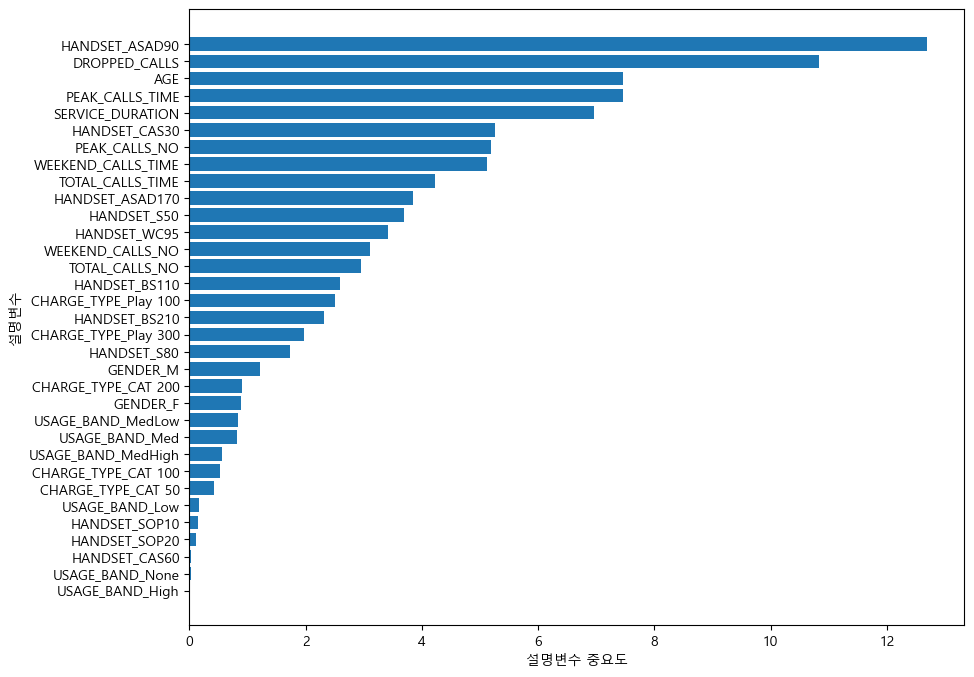

In [ ]:
# 설명변수 중요도 그래프
fig, ax = plt.subplots(figsize=(10, 8))

df_cbc_importance.sort_values("Importance", ascending=True, inplace=True)
coordinates = range(len(df_cbc_importance))
plt.barh(y=coordinates, width=df_cbc_importance["Importance"])
plt.yticks(coordinates, df_cbc_importance["Feature"])
plt.xlabel("설명변수 중요도")
plt.ylabel("설명변수")

## End of Boosting

# 서포터

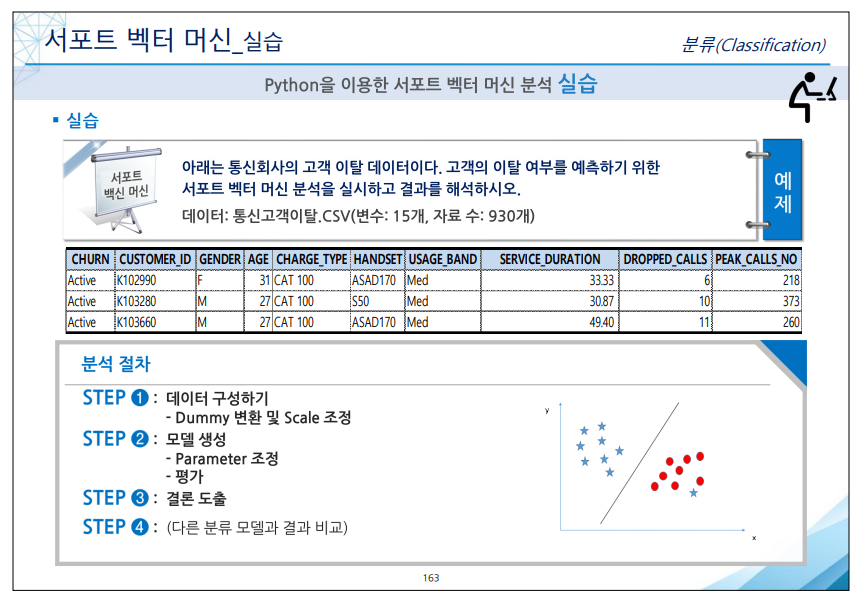

In [ ]:
# 데이터 구성:Series, DataFrame
import pandas as pd
import numpy as np
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 데이터 scaling
from sklearn.preprocessing import StandardScaler
# 데이터 분할:train, test
from sklearn.model_selection import train_test_split
# 분류 SVM
from sklearn.svm import SVC
# 최적 모델, 파라미터 탐색
from sklearn.model_selection import GridSearchCV

# 분류모델 평가 함수
from sklearn.metrics import accuracy_score, f1_score 
from sklearn.metrics import confusion_matrix, classification_report

#### 그래프 옵션 지정

In [ ]:
# 그래프 한글폰트 적용:맑은 고딕
matplotlib.rc("font", family = "Malgun Gothic")
# 그래프 (-) 기호 표시
matplotlib.rc("axes", unicode_minus = False)

### 데이터 구성하기

In [ ]:
# 데이터 불러오기
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\통신고객이탈.csv")
df_raw.head() 

,CHURN,CUSTOMER_ID,GENDER,AGE,CHARGE_TYPE,HANDSET,USAGE_BAND,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,Active,K102990,F,31,CAT 100,ASAD170,Med,33.33,6,218,379.8,9,21.6,366,632.4
1,Active,K103280,M,27,CAT 100,S50,Med,30.87,10,373,656.4,11,28.0,411,810.4
2,Active,K103660,M,27,CAT 100,ASAD170,Med,49.40,11,260,582.0,0,0.0,265,614.1
3,Active,K103730,M,61,CAT 100,ASAD170,Med,48.60,1,294,661.8,14,101.5,326,844.0
4,Active,K104560,F,52,CAT 100,S50,Med,56.03,0,221,555.6,7,25.0,274,673.0


In [ ]:
# Data 구조 확인
print("Data 구조:", df_raw.shape)
print()
print("변수 : ", df_raw.columns)

Data 구조: (930, 15)

변수 :  Index(['CHURN', 'CUSTOMER_ID', 'GENDER', 'AGE', 'CHARGE_TYPE', 'HANDSET',
       'USAGE_BAND', 'SERVICE_DURATION', 'DROPPED_CALLS', 'PEAK_CALLS_NO',
       'PEAK_CALLS_TIME', 'WEEKEND_CALLS_NO', 'WEEKEND_CALLS_TIME',
       'TOTAL_CALLS_NO', 'TOTAL_CALLS_TIME'],
      dtype='object')


#### 결측치 처리

In [ ]:
# 결측치 확인
df_raw.isnull().sum(axis = 0)

CHURN                 0
CUSTOMER_ID           0
GENDER                0
AGE                   0
CHARGE_TYPE           0
HANDSET               0
USAGE_BAND            0
SERVICE_DURATION      0
DROPPED_CALLS         0
PEAK_CALLS_NO         0
PEAK_CALLS_TIME       0
WEEKEND_CALLS_NO      0
WEEKEND_CALLS_TIME    0
TOTAL_CALLS_NO        0
TOTAL_CALLS_TIME      0
dtype: int64

#### 데이터 분리:목표변수/설명변수 분리

In [ ]:
# 목표변수/설명변수 분리 (제거할 컬럼들을 리스트로 묶어야 함)
df_raw_x = df_raw.drop(["CHURN", "CUSTOMER_ID"], axis = 1, inplace = False)
df_raw_y = df_raw["CHURN"] 

display("설명변수:", df_raw_x.head())
display("목표변수:", df_raw_y.head())

'설명변수:'

,GENDER,AGE,CHARGE_TYPE,HANDSET,USAGE_BAND,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,F,31,CAT 100,ASAD170,Med,33.33,6,218,379.8,9,21.6,366,632.4
1,M,27,CAT 100,S50,Med,30.87,10,373,656.4,11,28.0,411,810.4
2,M,27,CAT 100,ASAD170,Med,49.40,11,260,582.0,0,0.0,265,614.1
3,M,61,CAT 100,ASAD170,Med,48.60,1,294,661.8,14,101.5,326,844.0
4,F,52,CAT 100,S50,Med,56.03,0,221,555.6,7,25.0,274,673.0


'목표변수:'

0    Active
1    Active
2    Active
3    Active
4    Active
Name: CHURN, dtype: object

#### 범주형 설명변수 더미변환

df_raw_x_char만 더미 변환을 하면, AGE, SERVICE_DURATION 같은 숫자형(연속형) 변수들이 결과 데이터프레임(df_x_dummy)에서 모두 삭제됩니다. SVM 분석을 하려면 숫자 데이터와 더미 변환된 범주형 데이터가 모두 필요합니다.

In [ ]:
# 범주형 변수 선택 (단순 확인용)
df_raw_x_char = df_raw_x.select_dtypes(include = "object")

# get_dummies: df_raw_x_char가 아닌 df_raw_x를 넣어야 숫자 변수가 유지되면서 범주형만 변환됩니다.
df_x_dummy = pd.get_dummies(df_raw_x)

# 결과 확인
display("Dummy 변환 전 (범주형 변수):", df_raw_x_char.head())
display("Dummy 변환 후 (숫자 변수 포함 전체):", df_x_dummy.head())

'Dummy 변환 전 (범주형 변수):'

,GENDER,CHARGE_TYPE,HANDSET,USAGE_BAND
0,F,CAT 100,ASAD170,Med
1,M,CAT 100,S50,Med
2,M,CAT 100,ASAD170,Med
3,M,CAT 100,ASAD170,Med
4,F,CAT 100,S50,Med


'Dummy 변환 후 (숫자 변수 포함 전체):'

,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME,GENDER_F,...,HANDSET_S80,HANDSET_SOP10,HANDSET_SOP20,HANDSET_WC95,USAGE_BAND_High,USAGE_BAND_Low,USAGE_BAND_Med,USAGE_BAND_MedHigh,USAGE_BAND_MedLow,USAGE_BAND_None
0,31,33.33,6,218,379.8,9,21.6,366,632.4,1,...,0,0,0,0,0,0,1,0,0,0
1,27,30.87,10,373,656.4,11,28.0,411,810.4,0,...,0,0,0,0,0,0,1,0,0,0
2,27,49.40,11,260,582.0,0,0.0,265,614.1,0,...,0,0,0,0,0,0,1,0,0,0
3,61,48.60,1,294,661.8,14,101.5,326,844.0,0,...,0,0,0,0,0,0,1,0,0,0
4,52,56.03,0,221,555.6,7,25.0,274,673.0,1,...,0,0,0,0,0,0,1,0,0,0


#### 연속형 설명변수 scaling 변환

In [ ]:
# 연속형 변수 선택 : select_dtypes="object" 제외
df_raw_x_num = df_raw_x.select_dtypes(exclude = "object")

# 변수명 저장
v_feature_names = df_raw_x_num.columns

# StandardScaler 적용
scaler = StandardScaler()
df_x_scaled = scaler.fit_transform(df_raw_x_num)
df_x_scaled = pd.DataFrame(df_x_scaled, columns=v_feature_names)

# 스케일링된 연속형 변수와 이전에 만든 더미 변수(df_x_dummy) 결합
df_x_final = pd.concat([df_x_scaled, df_x_dummy], axis = 1)

# 결과 출력
display("Scale 변환 전:", df_raw_x_num.head())
display("Scale 변환 및 결합 후 (최종 설명변수):", df_x_final.head())

'Scale 변환 전:'

,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,31,33.33,6,218,379.8,9,21.6,366,632.4
1,27,30.87,10,373,656.4,11,28.0,411,810.4
2,27,49.40,11,260,582.0,0,0.0,265,614.1
3,61,48.60,1,294,661.8,14,101.5,326,844.0
4,52,56.03,0,221,555.6,7,25.0,274,673.0


'Scale 변환 및 결합 후 (최종 설명변수):'

,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME,AGE,...,HANDSET_S80,HANDSET_SOP10,HANDSET_SOP20,HANDSET_WC95,USAGE_BAND_High,USAGE_BAND_Low,USAGE_BAND_Med,USAGE_BAND_MedHigh,USAGE_BAND_MedLow,USAGE_BAND_None
0,-0.030604,-0.069958,0.949112,-0.032834,-0.617357,-0.432263,-0.755024,0.079015,-0.783880,31,...,0,0,0,0,0,0,1,0,0,0
1,-0.335827,-0.243451,2.091732,0.651830,-0.080674,-0.307456,-0.579614,0.259163,-0.458260,27,...,0,0,0,0,0,0,1,0,0,0
2,-0.335827,1.063386,2.377387,0.152687,-0.225031,-0.993897,-1.347031,-0.325316,-0.817357,27,...,0,0,0,0,0,0,1,0,0,0
3,2.258568,1.006966,-0.479163,0.302872,-0.070196,-0.120245,1.434855,-0.081116,-0.396795,61,...,0,0,0,0,0,0,1,0,0,0
4,1.571816,1.530970,-0.764818,-0.019583,-0.276254,-0.557071,-0.661838,-0.289287,-0.709610,52,...,0,0,0,0,0,0,1,0,0,0


#### 설명변수 데이터 결합: scale된 연속형 + dummy된 범주형

In [ ]:
# 설명변수 데이터 결합: scale된 연속형 + dummy된 범주형
# df_x_dummy에서 이미 스케일링한 연속형 변수들(v_feature_names)을 제거하고 합쳐야 합니다.
df_x_converted = df_x_scaled.join(df_x_dummy.drop(v_feature_names, axis=1).reset_index(drop=True))

display("변환 전:", df_raw_x.head())
display("Scale/Dummy 변환 후:", df_x_converted.head())

'변환 전:'

,GENDER,AGE,CHARGE_TYPE,HANDSET,USAGE_BAND,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,F,31,CAT 100,ASAD170,Med,33.33,6,218,379.8,9,21.6,366,632.4
1,M,27,CAT 100,S50,Med,30.87,10,373,656.4,11,28.0,411,810.4
2,M,27,CAT 100,ASAD170,Med,49.40,11,260,582.0,0,0.0,265,614.1
3,M,61,CAT 100,ASAD170,Med,48.60,1,294,661.8,14,101.5,326,844.0
4,F,52,CAT 100,S50,Med,56.03,0,221,555.6,7,25.0,274,673.0


'Scale/Dummy 변환 후:'

,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME,GENDER_F,...,HANDSET_S80,HANDSET_SOP10,HANDSET_SOP20,HANDSET_WC95,USAGE_BAND_High,USAGE_BAND_Low,USAGE_BAND_Med,USAGE_BAND_MedHigh,USAGE_BAND_MedLow,USAGE_BAND_None
0,-0.030604,-0.069958,0.949112,-0.032834,-0.617357,-0.432263,-0.755024,0.079015,-0.783880,1,...,0,0,0,0,0,0,1,0,0,0
1,-0.335827,-0.243451,2.091732,0.651830,-0.080674,-0.307456,-0.579614,0.259163,-0.458260,0,...,0,0,0,0,0,0,1,0,0,0
2,-0.335827,1.063386,2.377387,0.152687,-0.225031,-0.993897,-1.347031,-0.325316,-0.817357,0,...,0,0,0,0,0,0,1,0,0,0
3,2.258568,1.006966,-0.479163,0.302872,-0.070196,-0.120245,1.434855,-0.081116,-0.396795,0,...,0,0,0,0,0,0,1,0,0,0
4,1.571816,1.530970,-0.764818,-0.019583,-0.276254,-0.557071,-0.661838,-0.289287,-0.709610,1,...,0,0,0,0,0,0,1,0,0,0


1. 결과가 올바른 이유  
스케일링 적용 완료: AGE, SERVICE_DURATION 등의 연속형 변수들이 -0.0306... 처럼 표준화된 수치(Standard Scaling)로 변환되었습니다. 이는 거리 기반 모델인 SVM에서 필수적인 과정입니다.

변수 결합 성공: 5 rows × 33 columns라는 결과가 보여주듯, 스케일링된 숫자 변수들과 get_dummies를 통해 생성된 범주형 변수들이 중복 없이 하나로 합쳐졌습니다.

데이터 정합성: reset_index(drop=True)를 사용하여 인덱스를 맞췄기 때문에, 행이 어긋나지 않고 데이터가 정확하게 결합되었습니다.

2. 현재 상태 확인  
변환 전의 GENDER, CHARGE_TYPE, HANDSET 등은 현재 표의 오른쪽(33개 컬럼 중 뒷부분)에 0 또는 1의 값을 가진 더미 변수 형태로 잘 포함되어 있을 것입니다.

#### 데이터 분할:Train vs. Test

In [ ]:
# 변환된 설명변수 데이터 사용:df_x_converted 
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_x_converted, df_raw_y
                                    , test_size = 0.3, random_state = 1234)

print("분할된 Train Data: {}".format(df_train_x.shape))
print("분할된 Test Data: {}".format(df_test_x.shape))

분할된 Train Data: (651, 33)
분할된 Test Data: (279, 33)


## 모델 생성

#### 기본 옵션 모델 생성

In [ ]:
svm_uncust = SVC(random_state=1234)
svm_uncust.fit(df_train_x, df_train_y)

# train 모델 정확도
print("Train Accuracy : {:.3f}".format(svm_uncust.score(df_train_x, df_train_y)))
# test 모델 정확도
print("Test Accuracy : {:.3f}".format(svm_uncust.score(df_test_x, df_test_y)))

Train Accuracy : 0.906
Test Accuracy : 0.885


#### Cost 변경에 따른 모델 성능

In [ ]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []

para_c = [10 **c for c in range(-2, 3)] # 0.01, 0.1, 1, 10, 100 : 큰 변화 영향 확인
# para_c = [0.1 * c for c in range(1, 13)] )] # 0.1~1.0 : 작은 변화 영향 확인

for v_C in para_c:
    svm = SVC(C = v_C, random_state = 1234)
    svm.fit(df_train_x, df_train_y)
    train_accuracy.append(svm.score(df_train_x, df_train_y))
    test_accuracy.append(svm.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_c = pd.DataFrame()
df_accuracy_c["Cost"] = para_c
df_accuracy_c["TrainAccuracy"] = train_accuracy
df_accuracy_c["TestAccuracy"] = test_accuracy

In [ ]:
# Cost별 정확도
df_accuracy_c.round(3)

,Cost,TrainAccuracy,TestAccuracy
0,0.01,0.791,0.842
1,0.10,0.791,0.842
2,1.00,0.906,0.885
3,10.00,0.985,0.885
4,100.00,1.000,0.885


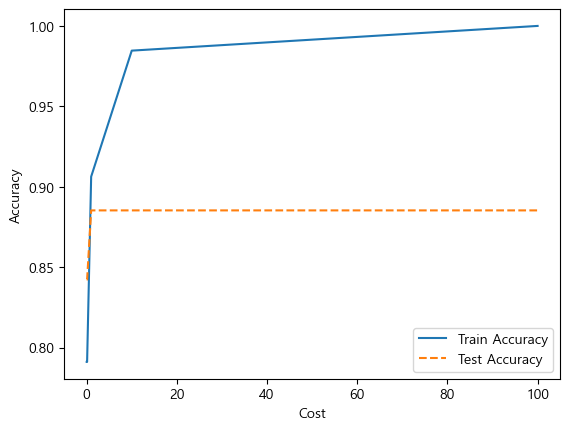

In [ ]:
# 정확도 그래프 확인
plt.plot(para_c, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_c, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Cost")
plt.legend()

10 이상이 되면  오히려 떨어진다>..?

1. 그래프 해석  
- Train Accuracy (파란 실선): $C$ 값이 커질수록 1.0(100%)에 가깝게 계속 상승합니다. 이는 모델이 학습 데이터를 더 엄격하게 외우고 있다는 뜻입니다.
- Test Accuracy (주황 점선): 초기에는 상승하다가 특정 지점(약 $C=10$ 부근) 이후로는 더 이상 오르지 않고 평탄하게 유지(Plateau)됩니다.
- 간격(Gap): $C$가 커질수록 두 선 사이의 간격이 벌어집니다. 이는 모델이 학습 데이터에만 지나치게 맞춰져서 실제 데이터(Test)에서는 성능이 나아지지 않는 과적합이 발생하고 있음을 의미합니다.

2. $C$ (Cost) 선정 기준  
가장 좋은 $C$를 고르는 기준은 다음 두 가지를 동시에 만족하는 지점입니다.  
- Test Accuracy가 최대인 지점 (가장 중요)
- Train과 Test Accuracy의 차이가 가장 적은 지점 (일반화 성능 고려)

3. 결론: 어떤 값을 골라야 하는가?  
이 그래프를 기준으로 본다면 $C=10$이 가장 적절합니다.  
- 이유: $C=10$에서 Test Accuracy가 최대치에 도달했으며, 그 이후($C=100$)로는 Test 성능은 그대로인데 Train 성능만 올라가며 간격이 벌어지기 때문입니다. 즉, $C$를 10보다 더 높이는 것은 모델을 복잡하게만 만들 뿐 실전 성능에는 도움이 되지 않습니다.

In [ ]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []

# para_c = [10 **c for c in range(-2, 3)] # 0.01, 0.1, 1, 10, 100 : 큰 변화 영향 확인
para_c = [0.1 * c for c in range(1, 13)] # 0.1~1.0 : 작은 변화 영향 확인

for v_C in para_c:
    svm = SVC(C = v_C, random_state = 1234)
    svm.fit(df_train_x, df_train_y)
    train_accuracy.append(svm.score(df_train_x, df_train_y))
    test_accuracy.append(svm.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_c = pd.DataFrame()
df_accuracy_c["Cost"] = para_c
df_accuracy_c["TrainAccuracy"] = train_accuracy
df_accuracy_c["TestAccuracy"] = test_accuracy

In [ ]:
# Cost별 정확도
df_accuracy_c.round(3)

,Cost,TrainAccuracy,TestAccuracy
0,0.1,0.791,0.842
1,0.2,0.791,0.842
2,0.3,0.791,0.842
3,0.4,0.791,0.842
4,0.5,0.797,0.839
5,0.6,0.837,0.835
6,0.7,0.856,0.860
7,0.8,0.876,0.864
8,0.9,0.902,0.875
9,1.0,0.906,0.885


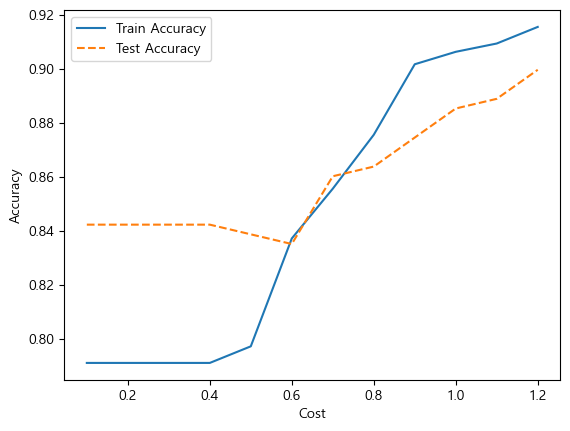

In [ ]:
# 정확도 그래프 확인
plt.plot(para_c, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_c, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Cost")
plt.legend()

1. 그래프 보는 법
- 주황색 점선(Test)이 높을수록 실제 성능이 좋은 것입니다.  
- 파란색 실선(Train)과 주황색 점선(Test)의 간격이 좁을수록 믿을만한 모델입니다.  
2. 고르는 기준
- 주황색 선이 가장 높게 올라간 지점을 찾으세요.
- 현재 그래프에서는 오른쪽 끝인 $C = 1.2$에서 성능이 가장 좋습니다.  
3. 한 줄 결론  
**$C = 1.2$**를 고르시면 됩니다. 테스트 정확도가 가장 높고, 학습 데이터와의 차이도 적어 아주 안정적인 상태입니다.

In [ ]:
# 실행옵션 확인
print(svm_uncust.get_params().keys())
print(svm_uncust.get_params().values())

dict_keys(['C', 'break_ties', 'cache_size', 'class_weight', 'coef0', 'decision_function_shape', 'degree', 'gamma', 'kernel', 'max_iter', 'probability', 'random_state', 'shrinking', 'tol', 'verbose'])
dict_values([1.0, False, 200, None, 0.0, 'ovr', 3, 'scale', 'rbf', -1, False, 1234, True, 0.001, False])


#### Gamma(데이터 영향 범위) 변경에 따른 모델 성능

5가지 케이스로 돌려보는 거임

In [ ]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []

para_gamma = [10 **gamma for gamma in range(-2, 3)]   # 0.01, 0.1, 1, 10, 100

for v_gamma in para_gamma:
    # 앞에서 선택한 최적의 C 값을 사용하는 것이 좋습니다 (예: 1.2)
    svm = SVC(gamma = v_gamma, C = 1.2, random_state = 1234)
    svm.fit(df_train_x, df_train_y)
    train_accuracy.append(svm.score(df_train_x, df_train_y))
    test_accuracy.append(svm.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_gamma = pd.DataFrame()
df_accuracy_gamma["gamma"] = para_gamma
df_accuracy_gamma["TrainAccuracy"] = train_accuracy
df_accuracy_gamma["TestAccuracy"] = test_accuracy

# 결과 출력
display(df_accuracy_gamma)

,gamma,TrainAccuracy,TestAccuracy
0,0.01,0.791091,0.842294
1,0.10,0.923195,0.906810
2,1.00,1.000000,0.842294
3,10.00,1.000000,0.842294
4,100.00,1.000000,0.842294


In [ ]:
# Gamma별 정확도
df_accuracy_gamma.round(4)

,gamma,TrainAccuracy,TestAccuracy
0,0.01,0.7911,0.8423
1,0.10,0.9232,0.9068
2,1.00,1.0000,0.8423
3,10.00,1.0000,0.8423
4,100.00,1.0000,0.8423


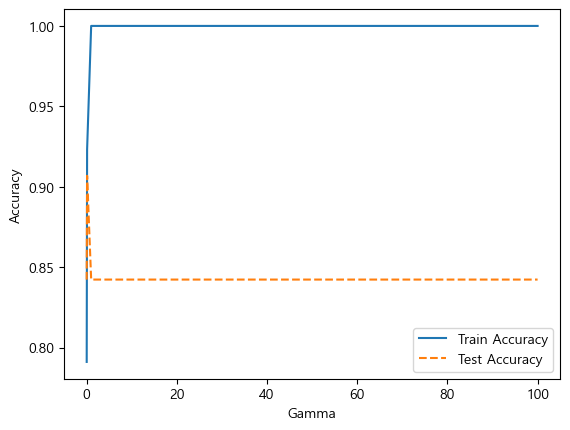

In [ ]:
# 모델 정확도 그래프 확인
plt.plot(para_gamma, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_gamma, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Gamma")  # X 축 범위 log 변환
plt.legend()

10 되니까 뚝 떨어져 그 전에서 감마를 정해야겠지

황색 선이 가장 높은 지점이자, 파란색 선과의 간격이 가장 좁은 지점을 골라야 합니다.

1. 그래프 해석  
감마(Gamma)가 커지면: 모델이 공부는 안 하고 답안지만 통째로 외우는 상태(과적합)가 됩니다.

결과: 파란 선(학습)은 100%가 되지만, 주황 선(실전)은 바닥을 칩니다.

2. 고르는 기준  
주황색 선이 가장 높게 솟아있는 지점을 찾으면 됩니다.

그래프 상의 맨 왼쪽 끝이 가장 좋습니다.

3. 한 줄 결론  
**gamma = 0.01**을 선택하세요. 값이 더 커지면 실전에서 쓸 수 없는 모델이 됩니다.

그 부분을 보자 아래에서

In [ ]:
# Gamma 미세 변화에 따른 모델 성능
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []

# para_gamma = [10 **gamma for gamma in range(-2, 3)]   # 0.01, 0.1, 1, 10, 100 : 큰 변화 영향 확인
para_gamma = [0.1 * gamma for gamma in range(1, 11)]     # 0.1~1.0 : 작은 변화 영향 확인

for v_gamma in para_gamma:
    svm = SVC(gamma = v_gamma, C = 1.2, random_state = 1234)
    svm.fit(df_train_x, df_train_y)
    train_accuracy.append(svm.score(df_train_x, df_train_y))
    test_accuracy.append(svm.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_gamma = pd.DataFrame()
df_accuracy_gamma["gamma"] = para_gamma
df_accuracy_gamma["TrainAccuracy"] = train_accuracy
df_accuracy_gamma["TestAccuracy"] = test_accuracy

In [ ]:
# Gamma별 정확도
df_accuracy_gamma.round(4)

,gamma,TrainAccuracy,TestAccuracy
0,0.1,0.9232,0.9068
1,0.2,0.9616,0.8710
2,0.3,0.9846,0.8495
3,0.4,0.9892,0.8530
4,0.5,0.9954,0.8530
5,0.6,0.9985,0.8530
6,0.7,0.9985,0.8495
7,0.8,0.9985,0.8423
8,0.9,1.0000,0.8423
9,1.0,1.0000,0.8423


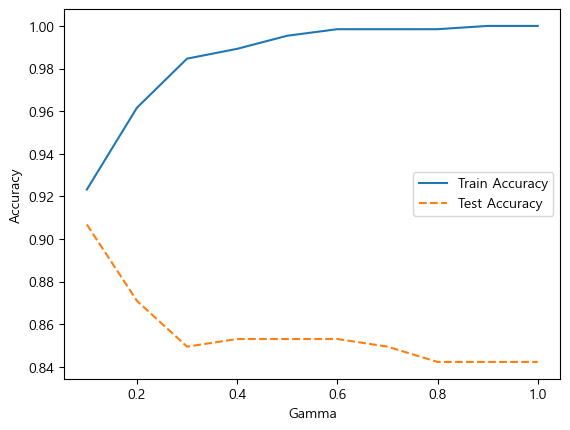

In [ ]:
# 모델 정확도 그래프 확인
plt.plot(para_gamma, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_gamma, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Gamma")  # X 축 범위 log 변환
plt.legend()

![image.png](attachment:image.png)

## 결론 도출

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. 최종 모델 생성: 앞서 찾은 최적 파라미터 반영 (C=1.2, gamma=0.1)
# 분석 결과에 따라 gamma=0.2, C=0.8보다 성능이 더 좋았던 값을 사용합니다.
svc_final = SVC(gamma=0.1, C=1.2, random_state=1234)
svc_final.fit(df_train_x, df_train_y)

# 2. 예측 및 평가
y_pred = svc_final.predict(df_test_x)

# 3. 결과 출력 (오타 수정: Accucary -> Accuracy)
print("Train Accuracy : {:.3f}".format(svc_final.score(df_train_x, df_train_y)))
print("Test Accuracy : {:.3f}\n".format(svc_final.score(df_test_x, df_test_y)))

# 4. Confusion Matrix 출력
print("Test Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)))

# 5. 목표변수의 빈도 불균형 고려: f1-score 포함 상세 리포트
print("\n[Classification Report]")
print(classification_report(df_test_y, y_pred, digits=3))

Train Accuracy : 0.923
Test Accuracy : 0.907

Test Confusion matrix: 
[[229   6]
 [ 20  24]]

[Classification Report]
              precision    recall  f1-score   support

      Active      0.920     0.974     0.946       235
     Churned      0.800     0.545     0.649        44

    accuracy                          0.907       279
   macro avg      0.860     0.760     0.797       279
weighted avg      0.901     0.907     0.899       279



디시젼 트리보다 쪼금 좋은거래

### Grid Search (12X10 = 120cases)

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. 모델 설정
estimator = SVC(random_state=1234)

# 2. 구하고자 하는 parameter와 범위 (이전에 정의한 para_c, para_gamma 사용)
param_grid = {"C": para_c,
              "gamma": para_gamma}

# 3. GridSearchCV 설정
# scoring="recall"은 이탈 고객을 놓치지 않겠다는 의도에 적합합니다.
grid_svc = GridSearchCV(estimator, param_grid, scoring="recall", n_jobs = -1)

# 4. 학습 (데이터 변수명을 df_train_x로 확인하십시오)
grid_svc.fit(df_train_x, df_train_y)

# 5. 결과 출력
print("best estimator model: \n{}".format(grid_svc.best_estimator_))
print("\nbest parameter: \n{}".format(grid_svc.best_params_))
print("\nbest score: \n{}".format(grid_svc.best_score_.round(3)))

best estimator model: 
SVC(C=0.1, gamma=0.1, random_state=1234)

best parameter: 
{'C': 0.1, 'gamma': 0.1}

best score: 
nan


c:\Users\User\.conda\envs\bigdata_env\lib\site-packages\sklearn\model_selection\_search.py:952: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


# NN


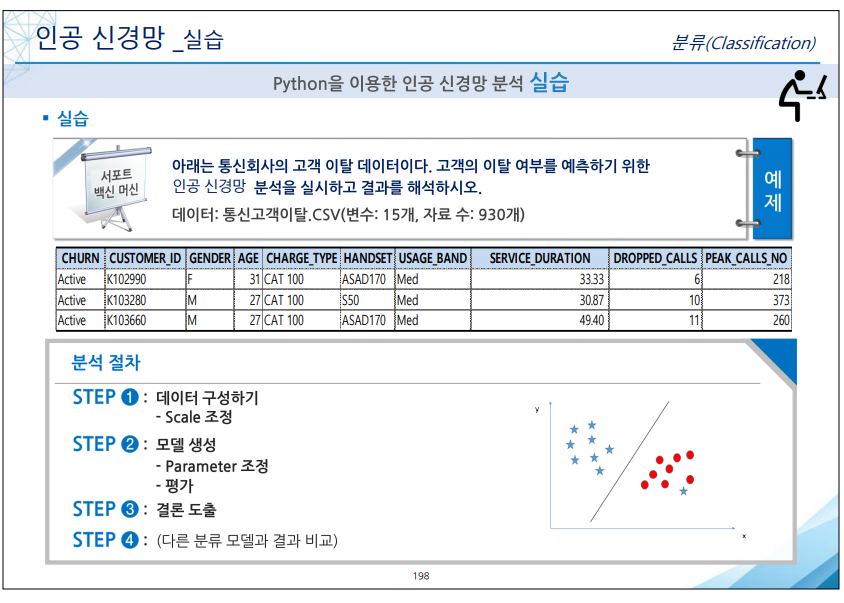

#### 패키지 불러오기

In [ ]:
# 데이터 구성:Series, DataFrame
import pandas as pd
import numpy as np
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 데이터 scaling
from sklearn.preprocessing import StandardScaler
# 데이터 분할:train, test
from sklearn.model_selection import train_test_split
# 분류 NN (MLPClassifier)
from sklearn.neural_network import MLPClassifier
# 최적 모델, 파라미터 탐색
from sklearn.model_selection import GridSearchCV

# 분류모델 평가 함수
from sklearn.metrics import accuracy_score, f1_score 
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# 경고 메세지 처리
import warnings
warnings.filterwarnings(action='ignore') # 경고 메시지 무시/숨김
# warnings.filterwarnings(action='default') # 경고 메시지 활성화

#### 그래프 옵션 지정

In [ ]:
# 그래프 한글폰트 적용:맑은 고딕
matplotlib.rc("font", family = "Malgun Gothic")
# 그래프 (-) 기호 표시
matplotlib.rc("axes", unicode_minus = False)

### 데이터 구성하기

In [ ]:
# 데이터 불러오기
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\통신고객이탈.csv")
df_raw.head() 

,CHURN,CUSTOMER_ID,GENDER,AGE,CHARGE_TYPE,HANDSET,USAGE_BAND,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,Active,K102990,F,31,CAT 100,ASAD170,Med,33.33,6,218,379.8,9,21.6,366,632.4
1,Active,K103280,M,27,CAT 100,S50,Med,30.87,10,373,656.4,11,28.0,411,810.4
2,Active,K103660,M,27,CAT 100,ASAD170,Med,49.40,11,260,582.0,0,0.0,265,614.1
3,Active,K103730,M,61,CAT 100,ASAD170,Med,48.60,1,294,661.8,14,101.5,326,844.0
4,Active,K104560,F,52,CAT 100,S50,Med,56.03,0,221,555.6,7,25.0,274,673.0


In [ ]:
# Data 구조 확인
print("Data 구조:", df_raw.shape)
print()
print("변수 : ", df_raw.columns)

Data 구조: (930, 15)

변수 :  Index(['CHURN', 'CUSTOMER_ID', 'GENDER', 'AGE', 'CHARGE_TYPE', 'HANDSET',
       'USAGE_BAND', 'SERVICE_DURATION', 'DROPPED_CALLS', 'PEAK_CALLS_NO',
       'PEAK_CALLS_TIME', 'WEEKEND_CALLS_NO', 'WEEKEND_CALLS_TIME',
       'TOTAL_CALLS_NO', 'TOTAL_CALLS_TIME'],
      dtype='object')


#### 결측치 처리

In [ ]:
# 결측치 확인
df_raw.isnull().sum(axis = 0)

CHURN                 0
CUSTOMER_ID           0
GENDER                0
AGE                   0
CHARGE_TYPE           0
HANDSET               0
USAGE_BAND            0
SERVICE_DURATION      0
DROPPED_CALLS         0
PEAK_CALLS_NO         0
PEAK_CALLS_TIME       0
WEEKEND_CALLS_NO      0
WEEKEND_CALLS_TIME    0
TOTAL_CALLS_NO        0
TOTAL_CALLS_TIME      0
dtype: int64

#### 데이터 분리:목표변수/설명변수 분리

In [ ]:
# 목표변수/설명변수 분리
df_raw_x = df_raw.drop("CHURN", axis = 1, inplace = False)
df_raw_y = df_raw["CHURN"] 

display("설명변수:", df_raw_x.head())
display("목표변수:",df_raw_y.head())

'설명변수:'

,CUSTOMER_ID,GENDER,AGE,CHARGE_TYPE,HANDSET,USAGE_BAND,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,K102990,F,31,CAT 100,ASAD170,Med,33.33,6,218,379.8,9,21.6,366,632.4
1,K103280,M,27,CAT 100,S50,Med,30.87,10,373,656.4,11,28.0,411,810.4
2,K103660,M,27,CAT 100,ASAD170,Med,49.40,11,260,582.0,0,0.0,265,614.1
3,K103730,M,61,CAT 100,ASAD170,Med,48.60,1,294,661.8,14,101.5,326,844.0
4,K104560,F,52,CAT 100,S50,Med,56.03,0,221,555.6,7,25.0,274,673.0


'목표변수:'

0    Active
1    Active
2    Active
3    Active
4    Active
Name: CHURN, dtype: object

#### 범주형 설명변수 더미변환

In [ ]:
# 범주형 변수 선택 (단순 확인용)
df_raw_x_char = df_raw_x.select_dtypes(include = "object")

# get_dummies: df_raw_x_char가 아닌 df_raw_x를 넣어야 숫자 변수가 유지되면서 범주형만 변환됩니다.
df_x_dummy = pd.get_dummies(df_raw_x)

# 결과 확인
display("Dummy 변환 전 (범주형 변수):", df_raw_x_char.head())
display("Dummy 변환 후 (숫자 변수 포함 전체):", df_x_dummy.head())

'Dummy 변환 전 (범주형 변수):'

,CUSTOMER_ID,GENDER,CHARGE_TYPE,HANDSET,USAGE_BAND
0,K102990,F,CAT 100,ASAD170,Med
1,K103280,M,CAT 100,S50,Med
2,K103660,M,CAT 100,ASAD170,Med
3,K103730,M,CAT 100,ASAD170,Med
4,K104560,F,CAT 100,S50,Med


'Dummy 변환 후 (숫자 변수 포함 전체):'

,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME,CUSTOMER_ID_K100420,...,HANDSET_S80,HANDSET_SOP10,HANDSET_SOP20,HANDSET_WC95,USAGE_BAND_High,USAGE_BAND_Low,USAGE_BAND_Med,USAGE_BAND_MedHigh,USAGE_BAND_MedLow,USAGE_BAND_None
0,31,33.33,6,218,379.8,9,21.6,366,632.4,0,...,0,0,0,0,0,0,1,0,0,0
1,27,30.87,10,373,656.4,11,28.0,411,810.4,0,...,0,0,0,0,0,0,1,0,0,0
2,27,49.40,11,260,582.0,0,0.0,265,614.1,0,...,0,0,0,0,0,0,1,0,0,0
3,61,48.60,1,294,661.8,14,101.5,326,844.0,0,...,0,0,0,0,0,0,1,0,0,0
4,52,56.03,0,221,555.6,7,25.0,274,673.0,0,...,0,0,0,0,0,0,1,0,0,0


#### 연속형 설명변수 scaling 변환

In [ ]:
# 연속형 변수 선택 : select_dtypes="object" 제외
df_raw_x_num = df_raw_x.select_dtypes(exclude = "object")

# 변수명 저장
v_feature_names = df_raw_x_num.columns

# StandardScaler 적용
scaler = StandardScaler()
df_x_scaled = scaler.fit_transform(df_raw_x_num)
df_x_scaled = pd.DataFrame(df_x_scaled, columns=v_feature_names)

# 스케일링된 연속형 변수와 이전에 만든 더미 변수(df_x_dummy) 결합
df_x_final = pd.concat([df_x_scaled, df_x_dummy], axis = 1)

# 결과 출력
display("Scale 변환 전:", df_raw_x_num.head())
display("Scale 변환 및 결합 후 (최종 설명변수):", df_x_final.head())

'Scale 변환 전:'

,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,31,33.33,6,218,379.8,9,21.6,366,632.4
1,27,30.87,10,373,656.4,11,28.0,411,810.4
2,27,49.40,11,260,582.0,0,0.0,265,614.1
3,61,48.60,1,294,661.8,14,101.5,326,844.0
4,52,56.03,0,221,555.6,7,25.0,274,673.0


'Scale 변환 및 결합 후 (최종 설명변수):'

,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME,AGE,...,HANDSET_S80,HANDSET_SOP10,HANDSET_SOP20,HANDSET_WC95,USAGE_BAND_High,USAGE_BAND_Low,USAGE_BAND_Med,USAGE_BAND_MedHigh,USAGE_BAND_MedLow,USAGE_BAND_None
0,-0.030604,-0.069958,0.949112,-0.032834,-0.617357,-0.432263,-0.755024,0.079015,-0.783880,31,...,0,0,0,0,0,0,1,0,0,0
1,-0.335827,-0.243451,2.091732,0.651830,-0.080674,-0.307456,-0.579614,0.259163,-0.458260,27,...,0,0,0,0,0,0,1,0,0,0
2,-0.335827,1.063386,2.377387,0.152687,-0.225031,-0.993897,-1.347031,-0.325316,-0.817357,27,...,0,0,0,0,0,0,1,0,0,0
3,2.258568,1.006966,-0.479163,0.302872,-0.070196,-0.120245,1.434855,-0.081116,-0.396795,61,...,0,0,0,0,0,0,1,0,0,0
4,1.571816,1.530970,-0.764818,-0.019583,-0.276254,-0.557071,-0.661838,-0.289287,-0.709610,52,...,0,0,0,0,0,0,1,0,0,0


#### 설명변수 데이터 결합: scale된 연속형 + dummy된 범주형

In [ ]:
# 설명변수 데이터 결합: scale된 연속형 + dummy된 범주형
# df_x_dummy에서 이미 스케일링한 연속형 변수들(v_feature_names)을 제거하고 합쳐야 합니다.
df_x_converted = df_x_scaled.join(df_x_dummy.drop(v_feature_names, axis=1).reset_index(drop=True))

display("변환 전:", df_raw_x.head())
display("Scale/Dummy 변환 후:", df_x_converted.head())

'변환 전:'

,CUSTOMER_ID,GENDER,AGE,CHARGE_TYPE,HANDSET,USAGE_BAND,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,K102990,F,31,CAT 100,ASAD170,Med,33.33,6,218,379.8,9,21.6,366,632.4
1,K103280,M,27,CAT 100,S50,Med,30.87,10,373,656.4,11,28.0,411,810.4
2,K103660,M,27,CAT 100,ASAD170,Med,49.40,11,260,582.0,0,0.0,265,614.1
3,K103730,M,61,CAT 100,ASAD170,Med,48.60,1,294,661.8,14,101.5,326,844.0
4,K104560,F,52,CAT 100,S50,Med,56.03,0,221,555.6,7,25.0,274,673.0


'Scale/Dummy 변환 후:'

,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME,CUSTOMER_ID_K100420,...,HANDSET_S80,HANDSET_SOP10,HANDSET_SOP20,HANDSET_WC95,USAGE_BAND_High,USAGE_BAND_Low,USAGE_BAND_Med,USAGE_BAND_MedHigh,USAGE_BAND_MedLow,USAGE_BAND_None
0,-0.030604,-0.069958,0.949112,-0.032834,-0.617357,-0.432263,-0.755024,0.079015,-0.783880,0,...,0,0,0,0,0,0,1,0,0,0
1,-0.335827,-0.243451,2.091732,0.651830,-0.080674,-0.307456,-0.579614,0.259163,-0.458260,0,...,0,0,0,0,0,0,1,0,0,0
2,-0.335827,1.063386,2.377387,0.152687,-0.225031,-0.993897,-1.347031,-0.325316,-0.817357,0,...,0,0,0,0,0,0,1,0,0,0
3,2.258568,1.006966,-0.479163,0.302872,-0.070196,-0.120245,1.434855,-0.081116,-0.396795,0,...,0,0,0,0,0,0,1,0,0,0
4,1.571816,1.530970,-0.764818,-0.019583,-0.276254,-0.557071,-0.661838,-0.289287,-0.709610,0,...,0,0,0,0,0,0,1,0,0,0


#### 데이터 분할:Train vs. Test

In [ ]:
# 변환된 설명변수 데이터 사용:df_x_converted 
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_x_converted, df_raw_y
                                    , test_size = 0.3, random_state = 1234)

print("분할된 Train Data: {}".format(df_train_x.shape))
print("분할된 Test Data: {}".format(df_test_x.shape))

분할된 Train Data: (651, 963)
분할된 Test Data: (279, 963)


## 모델 생성

#### 기본 옵션 모델 생성

In [ ]:
nn_uncust = MLPClassifier(random_state=1234)
nn_uncust.fit(df_train_x, df_train_y)

# train 모델 정확도
print("Train Accuracy: {:.3f}".format(nn_uncust.score(df_train_x, df_train_y)))
# test 모델 정확도
print("Test Accuracy: {:.3f}".format(nn_uncust.score(df_test_x, df_test_y)))

Train Accuracy: 1.000
Test Accuracy: 0.914


In [ ]:
# 실행옵션 확인
print(nn_uncust.get_params().keys())
print(nn_uncust.get_params().values())

dict_keys(['activation', 'alpha', 'batch_size', 'beta_1', 'beta_2', 'early_stopping', 'epsilon', 'hidden_layer_sizes', 'learning_rate', 'learning_rate_init', 'max_fun', 'max_iter', 'momentum', 'n_iter_no_change', 'nesterovs_momentum', 'power_t', 'random_state', 'shuffle', 'solver', 'tol', 'validation_fraction', 'verbose', 'warm_start'])
dict_values(['relu', 0.0001, 'auto', 0.9, 0.999, False, 1e-08, (100,), 'constant', 0.001, 15000, 200, 0.9, 10, True, 0.5, 1234, True, 'adam', 0.0001, 0.1, False, False])


#### Hidden Layer(은닉층) 변경에 따른 모델 성능

In [ ]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
para_hidden = [5 * hidden for hidden in range(1, 21)]  # 은닉층 노드 

print(para_hidden)

for v_hidden in para_hidden:
#     nn = MLPClassifier(hidden_layer_sizes = v_hidden, random_state = 1234) # 은닉층 : 1D (5,), (10,)...
    nn = MLPClassifier(hidden_layer_sizes = (v_hidden,v_hidden), random_state = 1234) # 은닉층 : 2D (5,5), (10,10)...
    nn.fit(df_train_x, df_train_y)
    train_accuracy.append(nn.score(df_train_x, df_train_y))
    test_accuracy.append(nn.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_hidden = pd.DataFrame()
df_accuracy_hidden["HiddenLayer"] = para_hidden
df_accuracy_hidden["TrainAccuracy"] = train_accuracy
df_accuracy_hidden["TestAccuracy"] = test_accuracy

[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]


In [ ]:
# 은닉층별 정확도
df_accuracy_hidden.round(3)

,HiddenLayer,TrainAccuracy,TestAccuracy
0,5,1.0,0.903
1,10,1.0,0.907
2,15,1.0,0.914
3,20,1.0,0.903
4,25,1.0,0.903
5,30,1.0,0.910
6,35,1.0,0.921
7,40,1.0,0.910
8,45,1.0,0.907
9,50,1.0,0.910


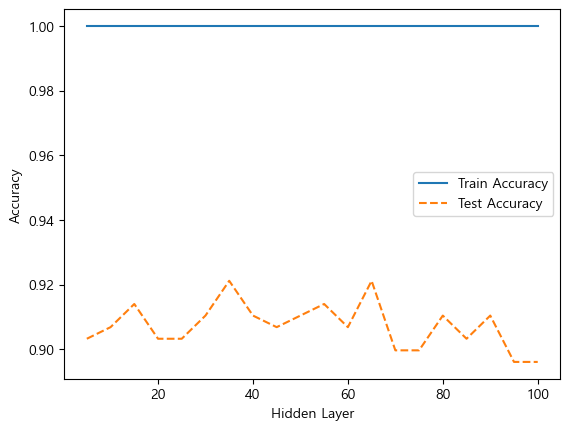

In [ ]:
# 정확도 그래프 확인
plt.plot(para_hidden, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_hidden, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Hidden Layer")
plt.legend()

1. 그래프 해석  
파란 실선 (Train): 이미 1.0(100%)에 딱 붙어 있습니다. 모델이 학습 데이터를 토씨 하나 안 틀리고 통째로 외워버린 상태입니다.

주황 점선 (Test): 은닉층(Hidden Layer)의 크기를 바꿀 때마다 실전 성적이 들쭉날쭉 요동치고 있습니다.

2. 현재 상태: 과적합 (Overfitting)  
연습문제(Train)는 만점인데 실전(Test)은 90~92점 사이에 머물러 있습니다. 모델이 너무 복잡해서 응용력은 없고 암기만 잘하는 상태입니다.

3. 고르는 기준  
주황색 선이 가장 높게 솟은 지점을 찾으세요.

그래프상으로는 35 혹은 65 부근이 실전 성적이 가장 좋습니다.

1. 뭘 정한 거지?  
은닉층(Hidden Layer)의 노드 수: 그래프 X축에 있는 숫자들입니다. 뇌로 치면 정보를 처리하는 세포의 수 혹은 지능의 크기를 몇 개로 할지 결정한 것입니다.

2. 왜 정하는 거야?  
적당한 지능을 찾아주기 위해서입니다.

너무 적으면: 머리가 나빠서 공부 내용을 이해 못 합니다 (학습 부족).

너무 많으면: 머리가 너무 좋아서 공부 내용을 이해하는 게 아니라, 문제와 답을 통째로 외워버립니다 (과적합).

#### Activation : 활성화 함수 변경에 따른 모델 성능

In [ ]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# activation 변경 
para_function = ["logistic", "tanh", "relu"]

for v_function in para_function:
    nn = MLPClassifier(activation = v_function, hidden_layer_sizes=(35,), random_state = 1234)
#     nn = MLPClassifier(activation = v_function, hidden_layer_sizes = (80,100,60), random_state = 1234) # 변경 가능
    nn.fit(df_train_x, df_train_y)
    train_accuracy.append(nn.score(df_train_x, df_train_y))
    test_accuracy.append(nn.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_function = pd.DataFrame()
df_accuracy_function["ActivationFunction"] = para_function
df_accuracy_function["TrainAccuracy"] = train_accuracy
df_accuracy_function["TestAccuracy"] = test_accuracy

In [ ]:
# Activation Function별 정확도 
df_accuracy_function.round(3)

,ActivationFunction,TrainAccuracy,TestAccuracy
0,logistic,0.968,0.925
1,tanh,1.000,0.910
2,relu,1.000,0.914


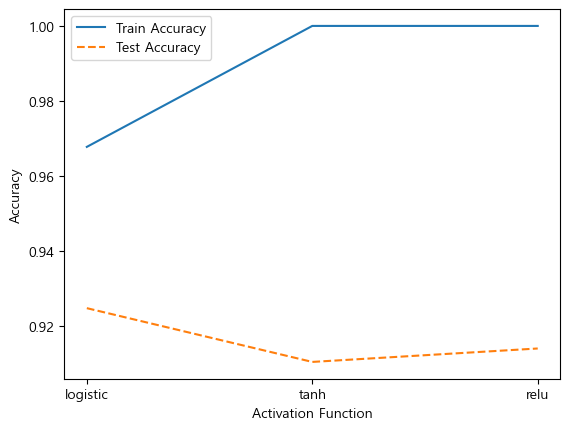

In [ ]:
# 모델 정확도 그래프 확인
plt.plot(para_function, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_function, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Activation Function")
plt.legend()

1. 뭘 정한 거지?  
인공지능의 '사고 방식' (활성화 함수)입니다. 들어온 정보를 다음 단계로 넘길 때 어떤 수학적 필터를 거칠지 결정한 것입니다.

2. 정하면 어떻게 돼?  
데이터를 해석하는 수학적 공식이 바뀝니다. 이에 따라 복잡한 문제를 이해하는 능력과 학습 속도가 달라집니다.

3. 결과 해석 및 결론  
현상: 파란 선(학습)은 이미 만점이라 암기 천재 상태입니다.

판단: 주황 선(실전)이 가장 높은 logistic 

한 줄 요약

실전 점수(주황 선)가 제일 높은 logistic 중 하나를 내 맘대로(?) 골라도 되는 단계입니다.

### Solver : 가중치 최적화 변경에 따른 모델 성능

In [ ]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# solver 변경 
para_solver = ["lbfgs", "sgd", "adam"]

for v_solver in para_solver:
    # 아까 찾은 최적의 히든레이어(35)와 활성화 함수(relu)를 적용합니다.
    nn = MLPClassifier(solver = v_solver, activation="logistic", hidden_layer_sizes=(35,), random_state = 1234)
    nn.fit(df_train_x, df_train_y)
    train_accuracy.append(nn.score(df_train_x, df_train_y))
    test_accuracy.append(nn.score(df_test_x, df_test_y))

# 데이터 테이블로 저장
df_accuracy_solver = pd.DataFrame()
df_accuracy_solver["Solver"] = para_solver
df_accuracy_solver["TrainAccuracy"] = train_accuracy
df_accuracy_solver["TestAccuracy"] = test_accuracy

display(df_accuracy_solver)

,Solver,TrainAccuracy,TestAccuracy
0,lbfgs,1.000000,0.896057
1,sgd,0.791091,0.842294
2,adam,0.967742,0.924731


In [ ]:
# Solver별 정확도 테이블
df_accuracy_solver.round(3)

,Solver,TrainAccuracy,TestAccuracy
0,lbfgs,1.000,0.896
1,sgd,0.791,0.842
2,adam,0.968,0.925


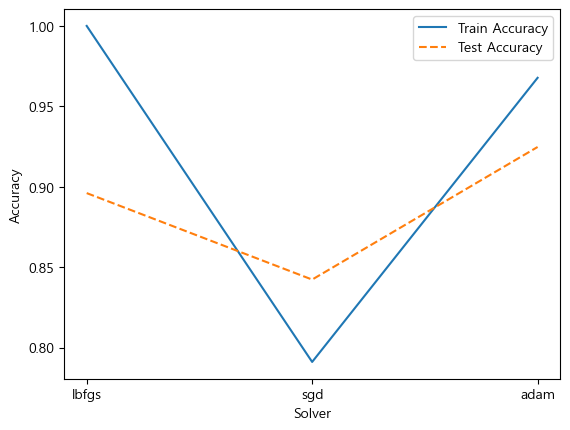

In [ ]:
# 정확도 그래프 확인
plt.plot(para_solver, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_solver, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Solver")
plt.legend()

#### Mini Batch 변경에 따른 모델 성능

In [ ]:
# train 및 test 정확도 결과 저장용
train_accuracy = []; test_accuracy = []
# Mini Batch 변경
para_batch = [20 * batch for batch in range(1, 10)] 

print(para_batch)

for v_batch in para_batch:
    nn = MLPClassifier(batch_size = v_batch, solver = "adam", activation = "logistic", 
                       hidden_layer_sizes = (35, ), random_state = 1234)
    nn.fit(df_train_x, df_train_y)
    train_accuracy.append(nn.score(df_train_x, df_train_y))
    test_accuracy.append(nn.score(df_test_x, df_test_y))    

# 데이터 테이블로 저장
df_accuracy_batch = pd.DataFrame()
df_accuracy_batch["Mini Batch"] = para_batch
df_accuracy_batch["TrainAccuracy"] = train_accuracy
df_accuracy_batch["TestAccuracy"] = test_accuracy

[20, 40, 60, 80, 100, 120, 140, 160, 180]


In [ ]:
# Mini Batch 별 정확도 
df_accuracy_batch.round(3)

,Mini Batch,TrainAccuracy,TestAccuracy
0,20,1.000,0.914
1,40,1.000,0.910
2,60,1.000,0.914
3,80,0.997,0.910
4,100,0.995,0.910
5,120,0.994,0.914
6,140,0.989,0.918
7,160,0.968,0.921
8,180,0.978,0.925


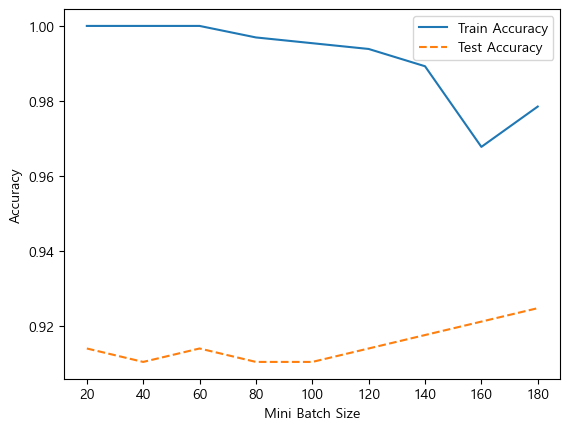

In [ ]:
# 모델 정확도 그래프 확인
plt.plot(para_batch, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_batch, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Mini Batch Size")
plt.legend()

1. 그래프 해석  
파란 실선 (Train): 배치 사이즈가 커질수록 1.0(만점)에서 조금씩 내려옵니다. 이는 무작정 외우기만 하던 습관이 줄어들고 있다는 좋은 신호입니다.

주황 점선 (Test): 그래프 오른쪽으로 갈수록 성적이 점점 올라가서 180 지점에서 가장 높은 점수를 찍었습니다.

2. 결론  
가장 높은 실전 성적을 낸 **180**을 선택하면 됩니다.

### 학습률 변경에 따른 모델 성능

In [ ]:
# train 및 test 정확도 결과 저장
train_accuracy = []; test_accuracy = []
# 학습률 변경: 0.001, 0.01, 0.1, 1.0
para_lr = [10 ** lr for lr in range(-3, 1)] 

for v_lr in para_lr:
    # activation을 "logistic"으로 수정했습니다.
    # batch_size는 아까 찾은 180을 넣어주는 것이 더 정확합니다.
    nn = MLPClassifier(learning_rate_init = v_lr, solver = "adam", activation = "logistic", 
                       hidden_layer_sizes = (35, ), batch_size = 180, random_state = 1234)
    nn.fit(df_train_x, df_train_y)
    train_accuracy.append(nn.score(df_train_x, df_train_y))
    test_accuracy.append(nn.score(df_test_x, df_test_y))    

# 데이터 테이블로 저장
df_accuracy_lr = pd.DataFrame()
df_accuracy_lr["Learning Rate"] = para_lr
df_accuracy_lr["TrainAccuracy"] = train_accuracy
df_accuracy_lr["TestAccuracy"] = test_accuracy

display(df_accuracy_lr)

,Learning Rate,TrainAccuracy,TestAccuracy
0,0.001,0.978495,0.924731
1,0.010,1.000000,0.906810
2,0.100,1.000000,0.910394
3,1.000,0.989247,0.867384


In [ ]:
# 학습률별 정확도 
df_accuracy_lr.round(3)

,Learning Rate,TrainAccuracy,TestAccuracy
0,0.001,0.978,0.925
1,0.010,1.000,0.907
2,0.100,1.000,0.910
3,1.000,0.989,0.867


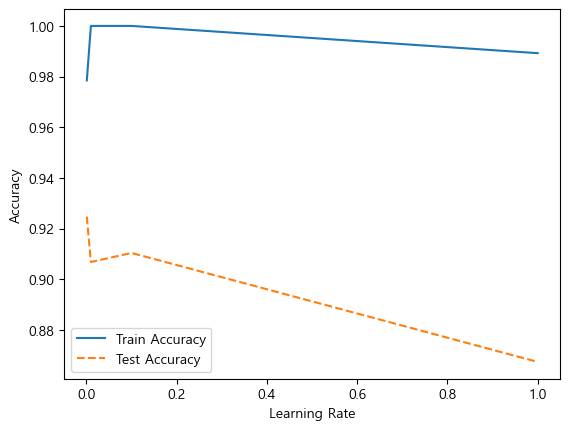

In [ ]:
# 모델 정확도 그래프 확인
plt.plot(para_lr, train_accuracy, linestyle = "-", label = "Train Accuracy")
plt.plot(para_lr, test_accuracy, linestyle = "--", label = "Test Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Learning Rate")
plt.legend()

1. 그래프 해석   
보폭이 커지면(오른쪽): 모델이 정답을 보지 못하고 휙휙 지나쳐버려서 실전 점수(주황 선)가 뚝 떨어집니다.

보폭이 작으면(왼쪽): 아주 신중하게 정답을 찾아가기 때문에 실전 성적이 가장 높습니다.

2. 선정 기준  
언제나처럼 주황색 점선이 가장 높게 솟은 지점을 고르면 됩니다.

그래프의 맨 왼쪽 끝인 0.001이 가장 좋은 성적을 내고 있습니다.

3. 한 줄 결론  
보폭(Learning Rate)을 가장 작게 설정한 **0.001**이 이번 모델의 최적값입니다.

드디어 모든 파라미터를 다 찾았습니다!

지능: 35

사고 방식: logistic

공부 방법: adam

학습 단위: 180

보폭: 0.001

# 모델평가

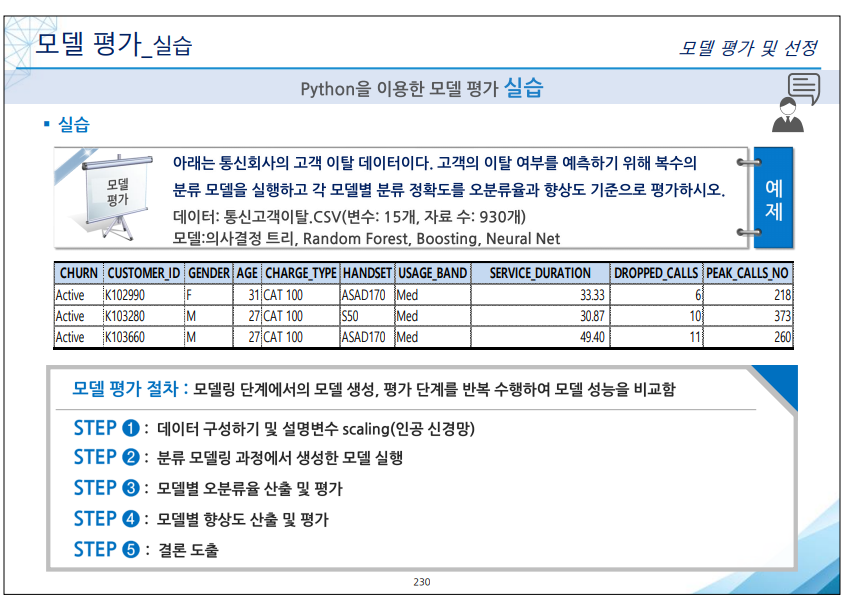

#### 패키지 불러오기

In [ ]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 데이터 scaling
from sklearn.preprocessing import StandardScaler
# 데이터 분할:train, test
from sklearn.model_selection import train_test_split

# 분류 Decision Tree
from sklearn.tree import DecisionTreeClassifier
# 분류 Random Forest
from sklearn.ensemble import RandomForestClassifier
# 분류 Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
# 분류 NN (MLPClassifier)
from sklearn.neural_network import MLPClassifier

# 모델 성능 평가: Precision, Recall, F1 Score, ROC Curve, AUC
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.metrics import confusion_matrix, classification_report

# Check the Frequency of Variable
from collections import Counter

#### 그래프 옵션 지정

In [ ]:
# 그래프 한글폰트 적용:맑은 고딕
matplotlib.rc("font", family = "Malgun Gothic")
# 그래프 (-) 기호 표시
matplotlib.rc("axes", unicode_minus = False)

### 데이터 구성하기

#### 데이터 불러오기

In [ ]:
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\통신고객이탈.csv")
df_raw.head()

,CHURN,CUSTOMER_ID,GENDER,AGE,CHARGE_TYPE,HANDSET,USAGE_BAND,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,Active,K102990,F,31,CAT 100,ASAD170,Med,33.33,6,218,379.8,9,21.6,366,632.4
1,Active,K103280,M,27,CAT 100,S50,Med,30.87,10,373,656.4,11,28.0,411,810.4
2,Active,K103660,M,27,CAT 100,ASAD170,Med,49.40,11,260,582.0,0,0.0,265,614.1
3,Active,K103730,M,61,CAT 100,ASAD170,Med,48.60,1,294,661.8,14,101.5,326,844.0
4,Active,K104560,F,52,CAT 100,S50,Med,56.03,0,221,555.6,7,25.0,274,673.0


In [ ]:
# Data 구조 확인
print("Data 구조:", df_raw.shape)
print()
print("변수 : ", df_raw.columns)

Data 구조: (930, 15)

변수 :  Index(['CHURN', 'CUSTOMER_ID', 'GENDER', 'AGE', 'CHARGE_TYPE', 'HANDSET',
       'USAGE_BAND', 'SERVICE_DURATION', 'DROPPED_CALLS', 'PEAK_CALLS_NO',
       'PEAK_CALLS_TIME', 'WEEKEND_CALLS_NO', 'WEEKEND_CALLS_TIME',
       'TOTAL_CALLS_NO', 'TOTAL_CALLS_TIME'],
      dtype='object')


####  교재에 없음:부연 설명-범주형 변수의 수준(level)별 빈도수 확인

#### 결측치 처리

In [ ]:
# 변수별 결측치 현황 확인
print(df_raw.isnull().sum(axis = 0))

# fillna: 결측치를 채우는 함수
# JOB 변수의 결측치는 Other로 입력, inplace: fillna 함수 적용 후 df_ raw 데이터에 저장, False면 저장 안 함
df_raw["CHURN"].fillna("Other", inplace = True)
# 숫자형 변수의 결측치는 해당 변수의 평균값 입력: df_raw.mean() 각 변수별 평균 계산 후 결측치 대체
df_raw.fillna(df_raw.mean(), inplace=True)

CHURN                 0
CUSTOMER_ID           0
GENDER                0
AGE                   0
CHARGE_TYPE           0
HANDSET               0
USAGE_BAND            0
SERVICE_DURATION      0
DROPPED_CALLS         0
PEAK_CALLS_NO         0
PEAK_CALLS_TIME       0
WEEKEND_CALLS_NO      0
WEEKEND_CALLS_TIME    0
TOTAL_CALLS_NO        0
TOTAL_CALLS_TIME      0
dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_10648\2681510663.py:8: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_raw.fillna(df_raw.mean(), inplace=True)


## 결측치 없네!

#### 데이터 분리:목표변수/설명변수 분리

In [ ]:
# 목표변수/설명변수 분리
df_raw_x = df_raw.drop("CHURN", axis = 1, inplace = False)
df_raw_y = df_raw["CHURN"] 

display("설명변수:", df_raw_x.head())
display("목표변수:",df_raw_y.head())

'설명변수:'

,CUSTOMER_ID,GENDER,AGE,CHARGE_TYPE,HANDSET,USAGE_BAND,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,K102990,F,31,CAT 100,ASAD170,Med,33.33,6,218,379.8,9,21.6,366,632.4
1,K103280,M,27,CAT 100,S50,Med,30.87,10,373,656.4,11,28.0,411,810.4
2,K103660,M,27,CAT 100,ASAD170,Med,49.40,11,260,582.0,0,0.0,265,614.1
3,K103730,M,61,CAT 100,ASAD170,Med,48.60,1,294,661.8,14,101.5,326,844.0
4,K104560,F,52,CAT 100,S50,Med,56.03,0,221,555.6,7,25.0,274,673.0


'목표변수:'

0    Active
1    Active
2    Active
3    Active
4    Active
Name: CHURN, dtype: object

#### 범주형 설명변수 더미변환

In [ ]:
# 범주형 변수 선택 (단순 확인용)
df_raw_x_char = df_raw_x.select_dtypes(include = "object")

# get_dummies: df_raw_x_char가 아닌 df_raw_x를 넣어야 숫자 변수가 유지되면서 범주형만 변환됩니다.
df_x_dummy = pd.get_dummies(df_raw_x)

# 결과 확인
display("Dummy 변환 전 (범주형 변수):", df_raw_x_char.head())
display("Dummy 변환 후 (숫자 변수 포함 전체):", df_x_dummy.head())

'Dummy 변환 전 (범주형 변수):'

,CUSTOMER_ID,GENDER,CHARGE_TYPE,HANDSET,USAGE_BAND
0,K102990,F,CAT 100,ASAD170,Med
1,K103280,M,CAT 100,S50,Med
2,K103660,M,CAT 100,ASAD170,Med
3,K103730,M,CAT 100,ASAD170,Med
4,K104560,F,CAT 100,S50,Med


'Dummy 변환 후 (숫자 변수 포함 전체):'

,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME,CUSTOMER_ID_K100420,...,HANDSET_S80,HANDSET_SOP10,HANDSET_SOP20,HANDSET_WC95,USAGE_BAND_High,USAGE_BAND_Low,USAGE_BAND_Med,USAGE_BAND_MedHigh,USAGE_BAND_MedLow,USAGE_BAND_None
0,31,33.33,6,218,379.8,9,21.6,366,632.4,0,...,0,0,0,0,0,0,1,0,0,0
1,27,30.87,10,373,656.4,11,28.0,411,810.4,0,...,0,0,0,0,0,0,1,0,0,0
2,27,49.40,11,260,582.0,0,0.0,265,614.1,0,...,0,0,0,0,0,0,1,0,0,0
3,61,48.60,1,294,661.8,14,101.5,326,844.0,0,...,0,0,0,0,0,0,1,0,0,0
4,52,56.03,0,221,555.6,7,25.0,274,673.0,0,...,0,0,0,0,0,0,1,0,0,0


#### 연속형 설명변수 scaling 변환

In [ ]:
# 연속형 변수 선택 : select_dtypes="object" 제외
df_raw_x_num = df_raw_x.select_dtypes(exclude = "object")

# 변수명 저장
v_feature_names = df_raw_x_num.columns

# StandardScaler 적용
scaler = StandardScaler()
df_x_scaled = scaler.fit_transform(df_raw_x_num)
df_x_scaled = pd.DataFrame(df_x_scaled, columns=v_feature_names)

# 스케일링된 연속형 변수와 이전에 만든 더미 변수(df_x_dummy) 결합
df_x_final = pd.concat([df_x_scaled, df_x_dummy], axis = 1)

# 결과 출력
display("Scale 변환 전:", df_raw_x_num.head())
display("Scale 변환 및 결합 후 (최종 설명변수):", df_x_final.head())

'Scale 변환 전:'

,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME
0,31,33.33,6,218,379.8,9,21.6,366,632.4
1,27,30.87,10,373,656.4,11,28.0,411,810.4
2,27,49.40,11,260,582.0,0,0.0,265,614.1
3,61,48.60,1,294,661.8,14,101.5,326,844.0
4,52,56.03,0,221,555.6,7,25.0,274,673.0


'Scale 변환 및 결합 후 (최종 설명변수):'

,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME,AGE,...,HANDSET_S80,HANDSET_SOP10,HANDSET_SOP20,HANDSET_WC95,USAGE_BAND_High,USAGE_BAND_Low,USAGE_BAND_Med,USAGE_BAND_MedHigh,USAGE_BAND_MedLow,USAGE_BAND_None
0,-0.030604,-0.069958,0.949112,-0.032834,-0.617357,-0.432263,-0.755024,0.079015,-0.783880,31,...,0,0,0,0,0,0,1,0,0,0
1,-0.335827,-0.243451,2.091732,0.651830,-0.080674,-0.307456,-0.579614,0.259163,-0.458260,27,...,0,0,0,0,0,0,1,0,0,0
2,-0.335827,1.063386,2.377387,0.152687,-0.225031,-0.993897,-1.347031,-0.325316,-0.817357,27,...,0,0,0,0,0,0,1,0,0,0
3,2.258568,1.006966,-0.479163,0.302872,-0.070196,-0.120245,1.434855,-0.081116,-0.396795,61,...,0,0,0,0,0,0,1,0,0,0
4,1.571816,1.530970,-0.764818,-0.019583,-0.276254,-0.557071,-0.661838,-0.289287,-0.709610,52,...,0,0,0,0,0,0,1,0,0,0


#### 설명변수 데이터 결합: scale된 연속형 + dummy된 범주형

1. 더미변수를 쓰고 x그대로 쓰고
2. xㄴ

In [ ]:
# 1. 원래 연속형 + dummy된 범주형
# pd.concat을 사용하고, 중복된 컬럼은 제거합니다.
df_x_raw_dummy = pd.concat([df_raw_x_num, df_x_dummy], axis=1)
df_x_raw_dummy = df_x_raw_dummy.loc[:, ~df_x_raw_dummy.columns.duplicated()]

# 2. scale된 연속형 + dummy된 범주형
df_x_scale_dummy = pd.concat([df_x_scaled, df_x_dummy], axis=1)
df_x_scale_dummy = df_x_scale_dummy.loc[:, ~df_x_scale_dummy.columns.duplicated()]

# 3. scale된 연속형 + 원래 범주형
df_x_scale_raw = pd.concat([df_x_scaled, df_raw_x_char], axis=1)
df_x_scale_raw = df_x_scale_raw.loc[:, ~df_x_scale_raw.columns.duplicated()]

#### 데이터 분할:Train vs. Test

In [ ]:
# 1. 원래 연속형 + Dummied 범주형...DT/RF/GB 용
# 중복 컬럼 에러 방지를 위해 pd.concat을 사용합니다.
df_x_raw_dummy = pd.concat([df_raw_x_num, df_x_dummy], axis=1)
df_x_raw_dummy = df_x_raw_dummy.loc[:, ~df_x_raw_dummy.columns.duplicated()]

df_train_x_rd, df_test_x_rd, df_train_y, df_test_y = train_test_split(df_x_raw_dummy, df_raw_y, 
                                                                    test_size = 0.3, random_state = 1234)
display("원래 연속형+ Dummied 범주형...DT/RF/GB 용:", df_train_x_rd.head())


# 2. Scaled 연속형 + Dummied 범주형...SVM/NN/KNN 용
df_x_scale_dummy = pd.concat([df_x_scaled, df_x_dummy], axis=1)
df_x_scale_dummy = df_x_scale_dummy.loc[:, ~df_x_scale_dummy.columns.duplicated()]

df_train_x_sd, df_test_x_sd, df_train_y, df_test_y = train_test_split(df_x_scale_dummy, df_raw_y, 
                                                                    test_size = 0.3, random_state = 1234)
display("Scaled 연속형+ Dummied 범주형...SVM/NN/KNN 용:", df_train_x_sd.head())


# 3. Scaled 연속형 + 원래 범주형...회귀분석용(표준화 회귀계수)
df_x_scale_raw = pd.concat([df_x_scaled, df_raw_x_char], axis=1)
df_x_scale_raw = df_x_scale_raw.loc[:, ~df_x_scale_raw.columns.duplicated()]

df_train_x_reg, df_test_x_reg, df_train_y, df_test_y = train_test_split(df_x_scale_raw, df_raw_y, 
                                                                      test_size = 0.3, random_state = 1234)
display("Scaled 연속형+ 원래 범주형...회귀분석용(표준화 회귀계수):", df_train_x_reg.head())

'원래 연속형+ Dummied 범주형...DT/RF/GB 용:'

,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME,CUSTOMER_ID_K100420,...,HANDSET_S80,HANDSET_SOP10,HANDSET_SOP20,HANDSET_WC95,USAGE_BAND_High,USAGE_BAND_Low,USAGE_BAND_Med,USAGE_BAND_MedHigh,USAGE_BAND_MedLow,USAGE_BAND_None
64,40,36.00,2,556,1436.4,8,74.0,736,1862.9,0,...,0,0,0,0,0,0,0,1,0,0
201,41,45.33,11,73,403.2,15,39.0,204,962.4,0,...,0,0,0,0,0,0,1,0,0,0
37,26,55.07,0,546,1228.2,0,0.0,588,1294.8,0,...,0,0,0,0,0,0,0,1,0,0
403,24,50.83,2,249,445.2,6,15.0,274,527.1,0,...,0,0,0,1,0,0,1,0,0,0
322,32,55.63,10,125,232.2,4,112.8,159,525.9,0,...,0,0,0,0,0,0,1,0,0,0


'Scaled 연속형+ Dummied 범주형...SVM/NN/KNN 용:'

,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME,CUSTOMER_ID_K100420,...,HANDSET_S80,HANDSET_SOP10,HANDSET_SOP20,HANDSET_WC95,USAGE_BAND_High,USAGE_BAND_Low,USAGE_BAND_Med,USAGE_BAND_MedHigh,USAGE_BAND_MedLow,USAGE_BAND_None
64,0.656147,0.118345,-0.193508,1.460175,1.432749,-0.494667,0.681142,1.560230,1.467105,0,...,0,0,0,0,0,0,0,1,0,0
201,0.732453,0.776348,2.377387,-0.673327,-0.571954,-0.057841,-0.278129,-0.569516,-0.180203,0,...,0,0,0,0,0,0,1,0,0,0
37,-0.412133,1.463266,-0.764818,1.416003,1.028781,-0.993897,-1.347031,0.967744,0.427865,0,...,0,0,0,0,0,0,0,1,0,0
403,-0.564745,1.164238,-0.193508,0.104098,-0.490462,-0.619475,-0.935915,-0.289287,-0.976508,0,...,0,0,0,1,0,0,1,0,0,0
322,0.045701,1.502760,2.091732,-0.443633,-0.903743,-0.744282,1.744562,-0.749664,-0.978704,0,...,0,0,0,0,0,0,1,0,0,0


'Scaled 연속형+ 원래 범주형...회귀분석용(표준화 회귀계수):'

,AGE,SERVICE_DURATION,DROPPED_CALLS,PEAK_CALLS_NO,PEAK_CALLS_TIME,WEEKEND_CALLS_NO,WEEKEND_CALLS_TIME,TOTAL_CALLS_NO,TOTAL_CALLS_TIME,CUSTOMER_ID,GENDER,CHARGE_TYPE,HANDSET,USAGE_BAND
64,0.656147,0.118345,-0.193508,1.460175,1.432749,-0.494667,0.681142,1.560230,1.467105,K124980,F,CAT 200,S50,MedHigh
201,0.732453,0.776348,2.377387,-0.673327,-0.571954,-0.057841,-0.278129,-0.569516,-0.180203,K165290,F,Play 300,ASAD170,Med
37,-0.412133,1.463266,-0.764818,1.416003,1.028781,-0.993897,-1.347031,0.967744,0.427865,K115360,F,CAT 200,S50,MedHigh
403,-0.564745,1.164238,-0.193508,0.104098,-0.490462,-0.619475,-0.935915,-0.289287,-0.976508,K280840,F,CAT 100,WC95,Med
322,0.045701,1.502760,2.091732,-0.443633,-0.903743,-0.744282,1.744562,-0.749664,-0.978704,K266260,M,Play 100,BS210,Med


## 최종 모델 실행

#### 평가 저장

In [ ]:
# 분석 모델 리스트
model = ["DecisionTree", "RandomForest", "GradientBoosting", "NeuralNet"]

# 정확도 저장
train_accuracy = []; test_accuracy = []
# auc score 저장
model_auc = []

# Precision, Recall score 저장
model_precision = []; model_recall = []
# f1 score 저장
model_f1_score = []

In [ ]:
model

['DecisionTree', 'RandomForest', 'GradientBoosting', 'NeuralNet']

### @의사결정나무

In [ ]:
# 최종모델
dt_final = DecisionTreeClassifier(max_depth=7, min_samples_split=50, min_samples_leaf=14, random_state=1234)
dt_final.fit(df_train_x_rd, df_train_y)

# 정확도
train_accuracy.append(dt_final.score(df_train_x_rd, df_train_y))
test_accuracy.append(dt_final.score(df_test_x_rd, df_test_y))

# 예측값
y_prob_1 = dt_final.predict_proba(df_test_x_rd)[:, 1]  # 1 발생 확률
y_pred = dt_final.predict(df_test_x_rd)  # 1/0 판정

print("Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)))
print(classification_report(df_test_y, y_pred, digits=3))

# fpr(=1-특이도) = FP/(FP+TN): 거짓 양성 비율, tpr(=민감도) = TP/(TP+FN): 진짜 양성 비율(재현율)
fpr, tpr, thresholds = roc_curve(df_test_y, y_prob_1 , pos_label='Churned')
roc_auc = auc(fpr, tpr)

# auc 저장
model_auc.append(roc_auc)

Confusion matrix: 
[[228   7]
 [ 17  27]]
              precision    recall  f1-score   support

      Active      0.931     0.970     0.950       235
     Churned      0.794     0.614     0.692        44

    accuracy                          0.914       279
   macro avg      0.862     0.792     0.821       279
weighted avg      0.909     0.914     0.909       279



In [ ]:
print("P(y=1) 확률...", y_prob_1)
print()
print("1/0-판정...",y_pred)

P(y=1) 확률... [0.03266332 0.03266332 0.03266332 0.19047619 0.47826087 0.90909091
 0.5        0.47826087 0.03266332 0.03266332 0.19047619 0.5
 0.03266332 0.03266332 0.19047619 0.86046512 0.03266332 0.03448276
 0.03266332 0.03266332 0.47826087 0.03266332 0.03266332 0.03266332
 0.5        0.17391304 0.03266332 0.17391304 0.03266332 0.03266332
 0.75       0.19047619 0.03266332 0.03266332 0.03266332 0.03448276
 0.03266332 0.03266332 0.03266332 0.03266332 0.03266332 0.47826087
 0.03266332 0.86046512 0.17391304 0.47826087 0.03266332 0.03266332
 0.90909091 0.03266332 0.03266332 0.03266332 0.03266332 0.19047619
 0.03266332 0.03266332 0.03448276 0.90909091 0.03266332 0.03266332
 0.23809524 0.86046512 0.5        0.03266332 0.03266332 0.03266332
 0.03266332 0.03266332 0.03266332 0.90909091 0.5        0.03266332
 0.03266332 0.03448276 0.03266332 0.03266332 0.03266332 0.03266332
 0.03266332 0.03266332 0.90909091 0.03266332 0.75       0.03266332
 0.17391304 0.03266332 0.75       0.03266332 0.86046512 

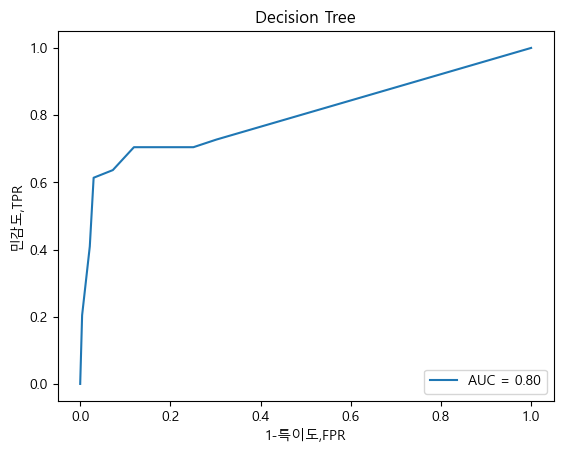

In [ ]:
plt.title("Decision Tree")
plt.plot(fpr, tpr, label= "AUC = %0.2f"% roc_auc)
plt.legend(loc="lower right")
plt.ylabel("민감도,TPR"); plt.xlabel("1-특이도,FPR") 
plt.show()

##### precision, recall, f1 score

In [ ]:
# precision, recall score
model_precision.append(precision_score(df_test_y, y_pred, pos_label='Churned'))
model_recall.append(recall_score(df_test_y, y_pred, pos_label='Churned'))

# f1 score
model_f1_score.append(f1_score(df_test_y, y_pred, pos_label='Churned'))
model_f1_score

[0.6923076923076923]

### @랜덤 포레스트

In [ ]:
# 최종 모델
rf_final = RandomForestClassifier(min_samples_leaf=20, max_depth=6, n_estimators=100, random_state=1234)
rf_final.fit(df_train_x_rd, df_train_y)

# 정확도
train_accuracy.append(rf_final.score(df_train_x_rd, df_train_y))
test_accuracy.append(rf_final.score(df_test_x_rd, df_test_y))

# 예측값
y_prob_1 = rf_final.predict_proba(df_test_x_rd)[:, 1]  # 1 발생 확률
y_pred = rf_final.predict(df_test_x_rd)  # 1/0 판정

print("Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)))
print(classification_report(df_test_y, y_pred, digits=3))

# fpr(=1-특이도) = FP/(FP+TN): 거짓 양성 비율, tpr(=민감도) = TP/(TP+FN): 진짜 양성 비율(재현율)
fpr, tpr, thresholds = roc_curve(df_test_y, y_prob_1, pos_label='Churned')
roc_auc = auc(fpr, tpr)

# auc 저장
model_auc.append(roc_auc)

Confusion matrix: 
[[235   0]
 [ 44   0]]
              precision    recall  f1-score   support

      Active      0.842     1.000     0.914       235
     Churned      0.000     0.000     0.000        44

    accuracy                          0.842       279
   macro avg      0.421     0.500     0.457       279
weighted avg      0.709     0.842     0.770       279



c:\Users\User\.conda\envs\bigdata_env\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\User\.conda\envs\bigdata_env\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\User\.conda\envs\bigdata_env\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


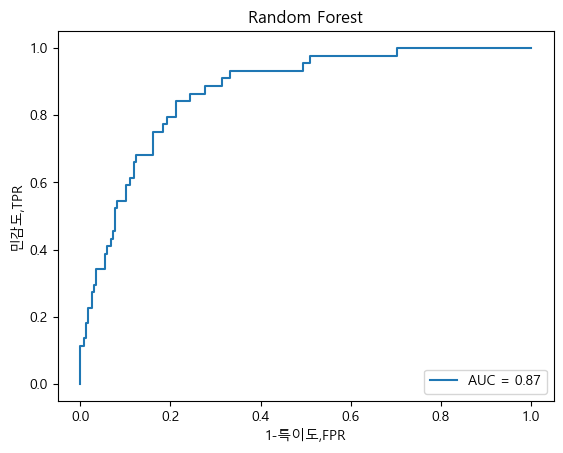

In [ ]:
plt.title("Random Forest")
plt.plot(fpr, tpr, label= "AUC = %0.2f"% roc_auc)
plt.legend(loc="lower right")
plt.ylabel("민감도,TPR"); plt.xlabel("1-특이도,FPR") 
plt.show()

##### precision, recall, f1 score

In [ ]:
# precision, recall score
model_precision.append(precision_score(df_test_y, y_pred, pos_label='Churned'))
model_recall.append(recall_score(df_test_y, y_pred, pos_label='Churned'))

# f1 score
model_f1_score.append(f1_score(df_test_y, y_pred, pos_label='Churned'))
model_f1_score

c:\Users\User\.conda\envs\bigdata_env\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


[0.6923076923076923, 0.0]

#### 그래디언트 부스팅

In [ ]:
# 최종 모델
gb_final = GradientBoostingClassifier(min_samples_leaf=15, max_depth=6, n_estimators=100,
			 learning_rate=0.1, random_state=1234)
gb_final.fit(df_train_x_rd, df_train_y)

# 정확도
train_accuracy.append(gb_final.score(df_train_x_rd, df_train_y))
test_accuracy.append(gb_final.score(df_test_x_rd, df_test_y))

# 예측값
y_prob_1 = gb_final.predict_proba(df_test_x_rd)[:, 1]  # 1 발생 확률
y_pred = gb_final.predict(df_test_x_rd)  # 1/0 판정

print("Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)),"\n")
print(classification_report(df_test_y, y_pred, digits=3))

# fpr(=1-특이도) = FP/(FP+TN): 거짓 양성 비율, tpr(=민감도) = TP/(TP+FN): 진짜 양성 비율(재현율)
fpr, tpr, thresholds = roc_curve(df_test_y, y_prob_1, pos_label='Churned')
roc_auc = auc(fpr, tpr)

# auc 저장
model_auc.append(roc_auc)

Confusion matrix: 
[[221  14]
 [ 15  29]] 

              precision    recall  f1-score   support

      Active      0.936     0.940     0.938       235
     Churned      0.674     0.659     0.667        44

    accuracy                          0.896       279
   macro avg      0.805     0.800     0.803       279
weighted avg      0.895     0.896     0.896       279



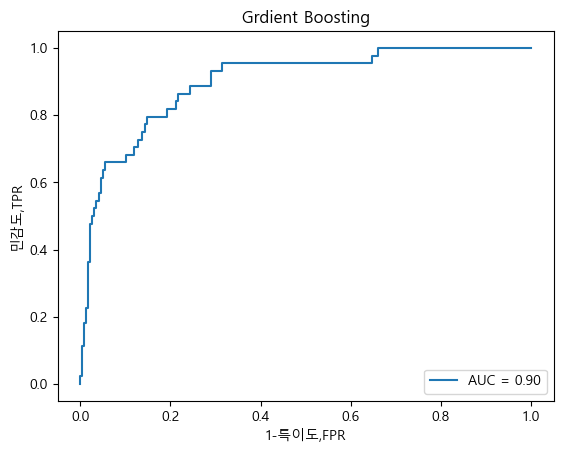

In [ ]:
plt.title("Grdient Boosting")
plt.plot(fpr, tpr, label= "AUC = %0.2f"% roc_auc)
plt.legend(loc="lower right")
plt.ylabel("민감도,TPR"); plt.xlabel("1-특이도,FPR") 
plt.show()

##### precision, recall, f1 score

In [ ]:
# precision, recall score
model_precision.append(precision_score(df_test_y, y_pred, pos_label='Churned'))
model_recall.append(recall_score(df_test_y, y_pred, pos_label='Churned'))

# f1 score
model_f1_score.append(f1_score(df_test_y, y_pred, pos_label='Churned'))
model_f1_score

[0.6923076923076923, 0.0, 0.6666666666666666]

### 인공신경망
    * df_train_x_sd/df_test_x_sd (Scaled 연속형+ Dummied 범주형) 사용 

In [ ]:
# 최종 모델
nn_final = MLPClassifier(hidden_layer_sizes=(80, 80), activation="relu", solver="adam", random_state = 1234)
nn_final.fit(df_train_x_sd, df_train_y)

# 정확도
train_accuracy.append(nn_final.score(df_train_x_sd, df_train_y))
test_accuracy.append(nn_final.score(df_test_x_sd, df_test_y))

# 예측값
y_prob_1 = nn_final.predict_proba(df_test_x_sd)[:, 1]  # 1 발생 확률
y_pred = nn_final.predict(df_test_x_sd)  # 1/0 판정

print("Confusion matrix: \n{}".format(confusion_matrix(df_test_y, y_pred)),"\n")
print(classification_report(df_test_y, y_pred, digits=3))

# fpr(=1-특이도) = FP/(FP+TN): 거짓 양성 비율, tpr(=민감도) = TP/(TP+FN): 진짜 양성 비율(재현율)
fpr, tpr, thresholds = roc_curve(df_test_y, y_prob_1, pos_label='Churned')
roc_auc = auc(fpr, tpr)

# auc 저장
model_auc.append(roc_auc)

Confusion matrix: 
[[223  12]
 [ 13  31]] 

              precision    recall  f1-score   support

      Active      0.945     0.949     0.947       235
     Churned      0.721     0.705     0.713        44

    accuracy                          0.910       279
   macro avg      0.833     0.827     0.830       279
weighted avg      0.910     0.910     0.910       279



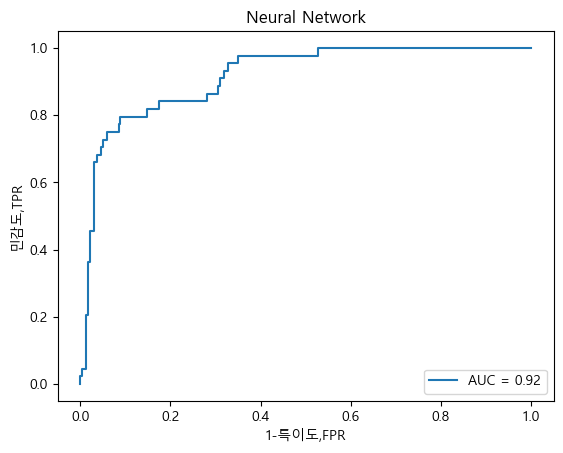

In [ ]:
plt.title("Neural Network")
plt.plot(fpr, tpr, label= "AUC = %0.2f"% roc_auc)
plt.legend(loc="lower right")
plt.ylabel("민감도,TPR"); plt.xlabel("1-특이도,FPR") 
plt.show()

##### precision, recall, f1 score

In [ ]:
# precision, recall score
model_precision.append(precision_score(df_test_y, y_pred, pos_label='Churned'))
model_recall.append(recall_score(df_test_y, y_pred, pos_label='Churned'))

# f1 score
model_f1_score.append(f1_score(df_test_y, y_pred, pos_label='Churned'))
model_f1_score

[0.6923076923076923, 0.0, 0.6666666666666666, 0.7126436781609196]

## 모델별 정확도 산출 및 평가

#### # 모델별 평가 결과

In [ ]:
# 모델별 평가 결과
df_eval = pd.DataFrame(index = model)
df_eval["TrainAccuracy"] = train_accuracy ; df_eval["TestAccuracy"] = test_accuracy
df_eval["AUC"] = model_auc

df_eval["Precision"] = model_precision; df_eval["Recall"] = model_recall
df_eval["F1Score"] = model_f1_score

df_eval.round(3)

,TrainAccuracy,TestAccuracy,AUC,Precision,Recall,F1Score
DecisionTree,0.885,0.914,0.800,0.794,0.614,0.692
RandomForest,0.791,0.842,0.871,0.000,0.000,0.000
GradientBoosting,0.998,0.896,0.899,0.674,0.659,0.667
NeuralNet,1.000,0.910,0.916,0.721,0.705,0.713


#### # 모델별 평가 지표 확인

In [ ]:
df_eval.T

,DecisionTree,RandomForest,GradientBoosting,NeuralNet
TrainAccuracy,0.884793,0.791091,0.998464,1.000000
TestAccuracy,0.913978,0.842294,0.896057,0.910394
AUC,0.800193,0.871083,0.898839,0.916344
Precision,0.794118,0.000000,0.674419,0.720930
Recall,0.613636,0.000000,0.659091,0.704545
F1Score,0.692308,0.000000,0.666667,0.712644


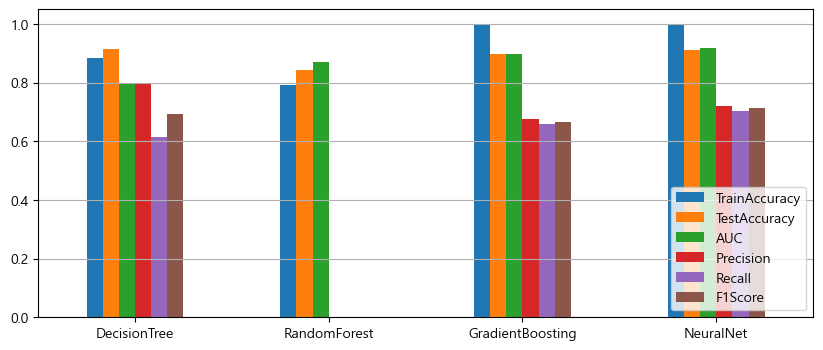

In [ ]:
# 모델별 평가 지표 확인
df_eval.plot.bar(rot = 0, figsize=(10,4))
plt.legend(loc="lower right"); plt.grid(axis = "y")

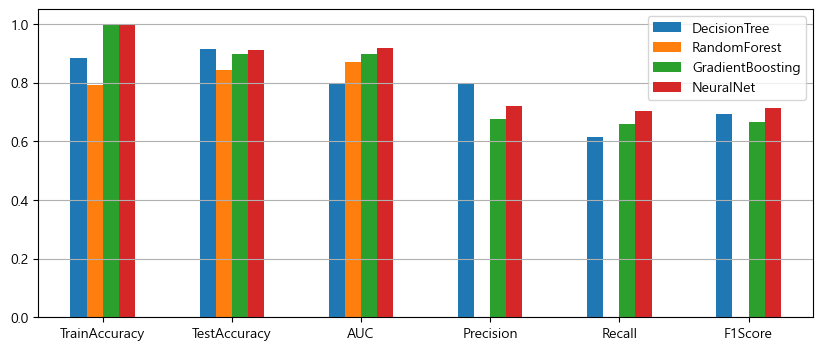

In [ ]:
# Data 전치하여 지표 기준으로 모델 성능 평가 
df_eval.T.plot.bar(rot = 0, figsize=(10,4))
plt.legend(loc="upper right"); plt.grid(axis = "y")

* 인공 신경망 모델이 가장 높은 정확도와 F1 score, AUC를 보임
* NeuralNet > GradientBoosting > DecisionTree > RandomForest

## End of 모델평가